# USA Economy Analysis

## 05-economic-analysis: What do these patterns mean economically?

## Imports

In [337]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_breusch_godfrey
from statsmodels.stats.diagnostic import het_breuschpagan

In [338]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

## Load dataset

In [339]:
Path_Data = Path("../data/processed/")
df_economy = pd.read_csv(Path_Data/ "USA_economy.csv")

# Question 1 — Major Expansion and Recession Periods

## What are the major expansion and recession periods in the U.S. economy, and what historical or economic events were associated with major turning points?

## 1. Economic Framework

### Business Cycles

A business cycle describes fluctuations in aggregate economic activity over time. A full business cycle is conventionally measured from trough to trough or from peak to peak.

### Peaks and Troughs

A peak marks the point at which economic activity reaches a local maximum before entering a contraction, while a trough marks the point at which economic activity reaches a local minimum before entering an expansion.

### Expansion and Recession

An expansion is the period from a trough to the next peak, while a recession is the period from a peak to the next trough.

The NBER Business Cycle Dating Committee maintains the official chronology of U.S. business cycles. According to the NBER, recessions are periods of significant contraction in economic activity between a peak and a trough, while expansions occur between a trough and the next peak.

### NBER Recession Dating

The NBER does not define recessions using a single mechanical rule such as two consecutive quarters of declining GDP. Instead, the committee evaluates a broad range of economic indicators and considers the depth, diffusion, and duration of changes in economic activity.

Therefore, the recession indicator used in this project should be interpreted as a data-based indicator rather than an official recession classification.

---

## 2. Historical Context

### Major U.S. Turning Points and Economic Events

The U.S. economy experienced several major contractions between 1974 and 2024. The official NBER chronology identifies seven recession periods within the sample:

| Recession | NBER Period |
|---|---|
| 1973–1975 | 1973Q4–1975Q1 |
| 1980 | 1980Q1–1980Q3 |
| 1981–1982 | 1981Q3–1982Q4 |
| 1990–1991 | 1990Q3–1991Q1 |
| 2001 | 2001Q1–2001Q4 |
| 2007–2009 | 2007Q4–2009Q2 |
| 2020 | 2020Q1–2020Q2 |

These downturns differed substantially in duration, severity, and underlying economic mechanisms.

---

## 3. Economic Mechanisms Behind Turning Points

### Demand Shocks

A demand shock is an unexpected change in aggregate spending that shifts the aggregate demand (AD) curve. A negative demand shock generally reduces output and inflationary pressure in the short run, while a positive demand shock tends to increase both.

### Supply Shocks

A supply shock is an unexpected change in production costs or productive capacity that shifts the aggregate supply (AS) curve. A negative supply shock can reduce output while simultaneously increasing the price level, creating a combination of weaker economic activity and higher inflation.

### Monetary Policy

Monetary policy refers to the strategies and actions used by the Federal Reserve to influence financial conditions and pursue its macroeconomic objectives.

Monetary tightening can reduce aggregate demand by increasing borrowing costs and weakening interest-sensitive consumption and investment. Although monetary tightening may be necessary to control inflation, it can also contribute to a temporary slowdown in economic activity.

### Financial and External Shocks

Financial and external shocks originate in credit and financial markets or from developments abroad. Depending on their transmission mechanism, they can affect the domestic economy through aggregate demand, aggregate supply, or both.

The 2007–2009 recession illustrates how a financial shock can spread to the broader economy through housing, credit markets, consumption, and investment.

---

## 4. Empirical Analysis

### Identifying Expansion and Recession Periods

The analysis uses quarterly U.S. economic data covering 1974Q1 to 2024Q1, consisting of 201 observations and 25 variables.

GDP growth and changes in the unemployment rate were used to construct a data-based recession indicator:

- GDP growth < 0
- Unemployment change > 0

This indicator identifies quarters in which economic activity contracted while labor-market conditions deteriorated.

The indicator identifies 9 recession-flagged quarters in the sample:

- 1982Q1
- 1990Q4
- 2001Q3
- 2008Q1
- 2008Q4–2009Q2
- 2020Q1–2020Q2

However, these observations should not be interpreted as the official beginning and ending dates of recessions. The indicator is intentionally mechanical and therefore does not capture the full duration of several NBER-defined recessions.

For example, the NBER identifies the 2007–2009 recession as a single continuous recession from 2007Q4 to 2009Q2, whereas the project's indicator flags only selected quarters within that period.

### Major Turning Points in the Data

The GDP growth series shows that major downturns differed considerably in magnitude.

The most severe quarterly contraction in the sample occurred in 2020Q2, when GDP growth fell to approximately -8.26%. This was accompanied by an unemployment rate of approximately 13%.

The 2007–2009 recession also produced a substantial deterioration in economic activity. GDP growth reached approximately -1.95% in 2008Q4 and remained negative through 2009Q2 in the data. At the same time, unemployment increased substantially, reaching 9.3% in 2009Q2.

The earlier downturns visible in the dataset were generally less extreme in terms of quarterly GDP contraction. For example, GDP growth reached approximately -0.20% in 1982Q1, -0.17% in 1990Q4, and -0.01% in 2001Q3.

The comparison between GDP growth and unemployment also illustrates an important feature of business cycles: economic activity and labor-market conditions do not necessarily move at exactly the same time or at the same speed. Unemployment can continue increasing after economic activity has begun to recover.

### GDP Growth and NBER Recessions

The GDP growth series was plotted together with official NBER recession periods.

The visualization shows that the major negative movements in GDP growth generally coincide with NBER-defined recessions. However, the magnitude of contractions varies substantially across recession episodes.

The 2020 recession is particularly unusual because the contraction was extremely sharp but very short, while the 2007–2009 recession was considerably longer and involved a prolonged deterioration in economic and financial conditions.

### Unemployment and NBER Recessions

The unemployment rate was also compared with NBER recession periods.

The data show a clear tendency for unemployment to increase during major economic contractions. The increase was especially pronounced during the 2007–2009 and 2020 recessions.

The relationship also demonstrates that the labor market may respond with a lag. Therefore, unemployment should be interpreted as a complementary indicator of recession dynamics rather than as an exact real-time measure of turning points.

---

## 5. Historical Interpretation

### Recession-by-Recession Discussion

#### 1973–1975 Recession

The 1973–1975 recession occurred during a period of high and rising inflation and major disruptions in energy markets. The 1973 oil embargo and the resulting increase in oil prices created a negative supply shock, increasing production costs and contributing to inflationary pressure.

The combination of supply-side pressures, inflation, and weakening economic activity contributed to a difficult macroeconomic environment characterized by elements of stagflation.

**Economic mechanism:** primarily a supply shock interacting with inflationary pressures and weakening aggregate demand.

---

#### 1980 Recession

The 1980 recession occurred during the broader period of the Great Inflation. The Federal Reserve tightened monetary policy in an effort to reduce persistent inflationary pressure.

Higher interest rates and tighter credit conditions weakened interest-sensitive spending and economic activity, contributing to the contraction.

**Economic mechanism:** monetary tightening → higher borrowing costs → weaker aggregate demand → recession.

---

#### 1981–1982 Recession

The 1981–1982 recession was closely associated with the Federal Reserve's aggressive anti-inflation policy under Chairman Paul Volcker.

The Fed maintained restrictive monetary conditions despite the deterioration in economic activity in order to reduce inflation and inflation expectations. Higher interest rates particularly affected interest-sensitive sectors such as manufacturing and construction.

The recession was severe enough for unemployment to approach 11% by the end of 1982.

**Economic mechanism:** restrictive monetary policy → weaker credit and investment → lower aggregate demand → higher unemployment.

---

#### 1990–1991 Recession

The 1990–1991 recession was relatively moderate compared with the early-1980s and 2007–2009 downturns.

The recession occurred alongside the 1990 oil-price shock following Iraq's invasion of Kuwait and a weakening of domestic economic activity. Financial-sector problems, including difficulties in the savings and loan industry, also contributed to weaker financial conditions.

**Economic mechanism:** external supply shock + financial weakness + weaker aggregate demand.

---

#### 2001 Recession

The 2001 recession followed the bursting of the dot-com investment bubble and a substantial decline in business investment, particularly in technology-related sectors.

The September 11 attacks in 2001 created an additional negative shock to economic activity and financial markets.

Unlike the Great Recession, the 2001 downturn was relatively mild in terms of the contraction in aggregate output, although unemployment increased as labor-market conditions deteriorated.

**Economic mechanism:** investment and financial shock → weaker business investment and aggregate demand → slower economic activity.

---

#### 2007–2009 Great Recession

The 2007–2009 recession was associated with the collapse of the U.S. housing market and the resulting financial crisis.

Declining house prices increased mortgage defaults and losses on mortgage-related financial assets. Financial stress spread through credit markets, reducing the availability of credit to households and firms.

The resulting contraction in housing, consumption, investment, and credit conditions produced a severe decline in aggregate demand.

The data in this project capture the sharp deterioration particularly clearly during 2008–2009, when GDP growth became strongly negative and unemployment increased substantially.

**Economic mechanism:** housing-market collapse → financial stress → credit contraction → lower consumption and investment → severe decline in aggregate demand.

---

#### 2020 COVID-19 Recession

The 2020 recession was fundamentally different from most earlier recessions in the sample.

The COVID-19 pandemic led to widespread restrictions on economic activity, disrupting production and supply chains while simultaneously reducing consumption, employment, and investment.

The result was an exceptionally rapid contraction. In the project's dataset, GDP growth fell to approximately -8.26% in 2020Q2, while the unemployment rate reached approximately 13%.

The economy then experienced a very rapid rebound, with GDP growth reaching approximately 8.71% in 2020Q3.

**Economic mechanism:** simultaneous supply and demand shocks → abrupt contraction in economic activity → exceptional increase in unemployment → rapid policy-supported recovery.

---

## 6. Economic Interpretation

The empirical and historical evidence suggests that U.S. recessions do not have a single recurring cause. Different downturns have been associated with different combinations of supply shocks, demand contractions, monetary tightening, financial disturbances, and external shocks.

Several important patterns emerge from the data.

First, recession severity varies substantially across episodes. The 2020 recession produced the sharpest quarterly contraction in GDP in the sample, while the 2007–2009 recession was notable for its depth and duration.

Second, unemployment generally deteriorates during major contractions, but its response is not perfectly synchronized with GDP. This means that labor-market indicators provide important complementary information when identifying and interpreting business-cycle turning points.

Third, the comparison between the project's recession indicator and the NBER chronology demonstrates the limitations of mechanical recession rules. A simple combination of negative GDP growth and rising unemployment can identify important downturns, but it cannot fully reproduce the official recession chronology.

Finally, major turning points often reflect interactions between multiple economic mechanisms rather than a single shock. For example, the 2007–2009 recession involved housing-market weakness, financial distress, credit contraction, and declining aggregate demand, while the 2020 recession combined unusually large supply and demand shocks.

Overall, the evidence supports the view that business-cycle fluctuations are the result of complex interactions between real economic shocks, financial conditions, expectations, and macroeconomic policy.

---

## 7. Conclusion

The U.S. economy experienced seven NBER-defined recessions between 1974 and 2024, with substantial differences in their duration, severity, and underlying causes.

The empirical analysis shows that major recessions are generally associated with declining economic activity and deteriorating labor-market conditions, but the timing and magnitude of these responses differ across episodes.

The historical analysis further shows that major turning points have been associated with several different mechanisms, including oil and supply shocks, restrictive monetary policy, investment and financial shocks, housing-market and credit crises, and the COVID-19 pandemic.

The comparison with the NBER chronology also demonstrates why recession identification cannot rely on a single mechanical rule. Economic downturns are multidimensional events, and understanding them requires combining quantitative indicators with historical and economic context.

Therefore, the major lesson from the U.S. business-cycle history examined in this project is that recessions are not uniform events. Their origins, transmission mechanisms, and effects on output and employment depend heavily on the type of shock and the economic environment in which it occurs.

### Q1 Data audit

In [340]:
df_economy.shape

(201, 25)

In [341]:
df_economy.columns.tolist()

['year',
 'quarter',
 'year-quarter',
 'gdp',
 'cpi',
 'unemployment_rate',
 'gdp_growth',
 'cpi_growth',
 'unemployment_change',
 'gdp_yoy',
 'cpi_yoy',
 'unemployment_yoy_change',
 'gdp_rolling_mean_4q',
 'cpi_rolling_mean_4q',
 'unemployment_rolling_mean_4q',
 'gdp_volatility_4q',
 'cpi_volatility_4q',
 'unemployment_volatility_4q',
 'gdp_growth_lag1',
 'gdp_growth_lag2',
 'cpi_growth_lag1',
 'unemployment_change_lag1',
 'covid_flag',
 'recession_flag',
 'high_growth_flag']

In [342]:
df_economy[['year-quarter', 'gdp_growth', 'unemployment_rate', 'unemployment_change', 'recession_flag']].head(10)

,year-quarter,gdp_growth,unemployment_rate,unemployment_change,recession_flag
0,1974Q1,NaN,5.1333,NaN,False
1,1974Q2,0.0261,5.2000,0.0667,False
2,1974Q3,0.0196,5.6333,0.4333,False
3,1974Q4,0.0254,6.6000,0.9667,False
4,1975Q1,0.0103,8.2667,1.6667,False
5,1975Q2,0.0221,8.8667,0.6000,False
6,1975Q3,0.0351,8.4667,-0.4000,False
7,1975Q4,0.0304,8.3000,-0.1667,False
8,1976Q1,0.0333,7.7333,-0.5667,False
9,1976Q2,0.0175,7.5667,-0.1667,False


### Episode analysis

In [343]:
df_economy['recession_flag'].value_counts()

recession_flag
False    192
True       9
Name: count, dtype: int64

In [344]:
df_economy[
    ['year-quarter', 'gdp_growth', 'unemployment_rate',
     'unemployment_change', 'recession_flag']
].query('recession_flag == True')

,year-quarter,gdp_growth,unemployment_rate,unemployment_change,recession_flag
32,1982Q1,-0.0020,8.8333,0.6000,True
67,1990Q4,-0.0017,6.1333,0.4333,True
110,2001Q3,-0.0001,4.8333,0.4333,True
136,2008Q1,-0.0006,5.0000,0.2000,True
139,2008Q4,-0.0195,6.8667,0.8667,True
140,2009Q1,-0.0121,8.2667,1.4000,True
141,2009Q2,-0.0034,9.3000,1.0333,True
184,2020Q1,-0.0089,3.8333,0.2333,True
185,2020Q2,-0.0826,13.0000,9.1667,True


### Recession severity

#### Major downturns

In [345]:
df_economy.nsmallest(
    10,
    'gdp_growth'
)[[
    'year-quarter',
    'gdp_growth',
    'unemployment_rate',
    'unemployment_change'
]]

,year-quarter,gdp_growth,unemployment_rate,unemployment_change
185,2020Q2,-0.0826,13.0000,9.1667
139,2008Q4,-0.0195,6.8667,0.8667
140,2009Q1,-0.0121,8.2667,1.4000
184,2020Q1,-0.0089,3.8333,0.2333
141,2009Q2,-0.0034,9.3000,1.0333
32,1982Q1,-0.0020,8.8333,0.6000
67,1990Q4,-0.0017,6.1333,0.4333
136,2008Q1,-0.0006,5.0000,0.2000
110,2001Q3,-0.0001,4.8333,0.4333
160,2014Q1,0.0003,6.6667,-0.2667


#### Major expansion

In [346]:
df_economy.nlargest(
    10,
    'gdp_growth'
)[[
    'year-quarter',
    'gdp_growth',
    'unemployment_rate',
    'unemployment_change'
]]

,year-quarter,gdp_growth,unemployment_rate,unemployment_change
186,2020Q3,0.0871,8.8000,-4.2000
17,1978Q2,0.0585,6.0000,-0.3333
28,1981Q1,0.0464,7.4333,0.0333
27,1980Q4,0.0452,7.4000,-0.2667
6,1975Q3,0.0351,8.4667,-0.4000
191,2021Q4,0.0346,4.1667,-0.9000
19,1978Q4,0.0342,5.9000,-0.1333
13,1977Q2,0.0338,7.1333,-0.3667
8,1976Q1,0.0333,7.7333,-0.5667
30,1981Q3,0.0310,7.4000,0.0000


### Plot

In [347]:
df_plot = df_economy.copy()

df_plot['period'] = pd.PeriodIndex(
    df_plot['year-quarter'],
    freq='Q'
)

#### GDP

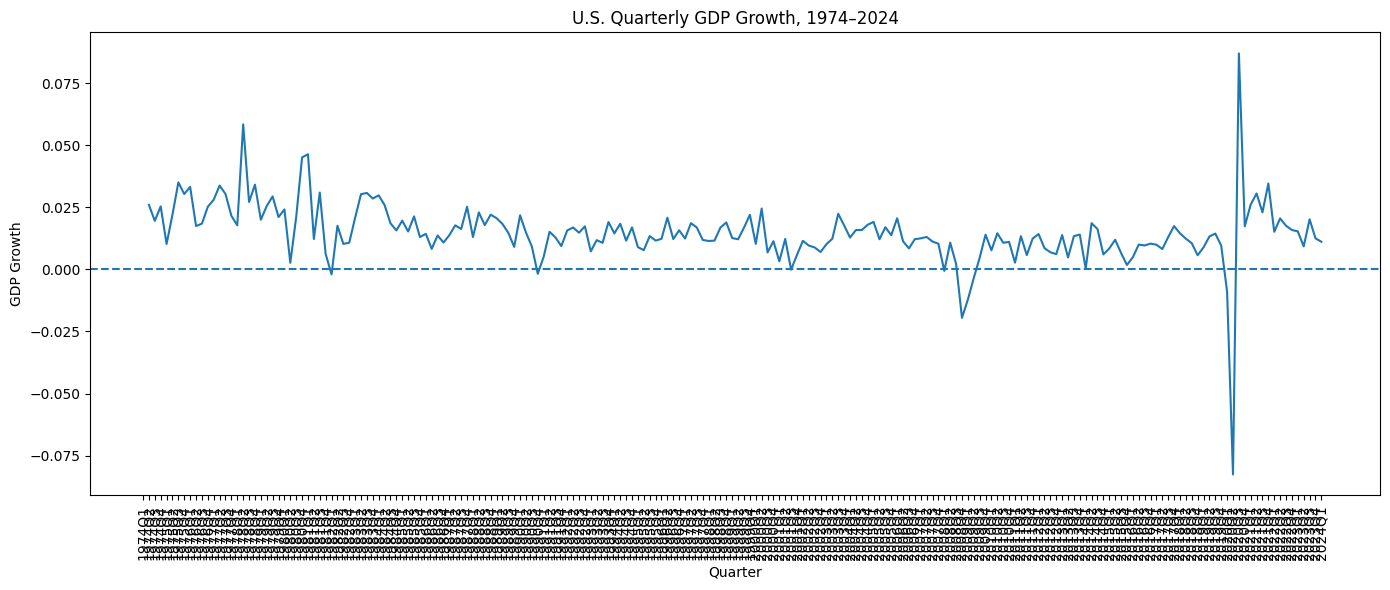

In [348]:
plt.figure(figsize=(14, 6))

plt.plot(
    df_plot['period'].astype(str),
    df_plot['gdp_growth']
)

plt.axhline(0, linestyle='--')

plt.title('U.S. Quarterly GDP Growth, 1974–2024')
plt.xlabel('Quarter')
plt.ylabel('GDP Growth')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

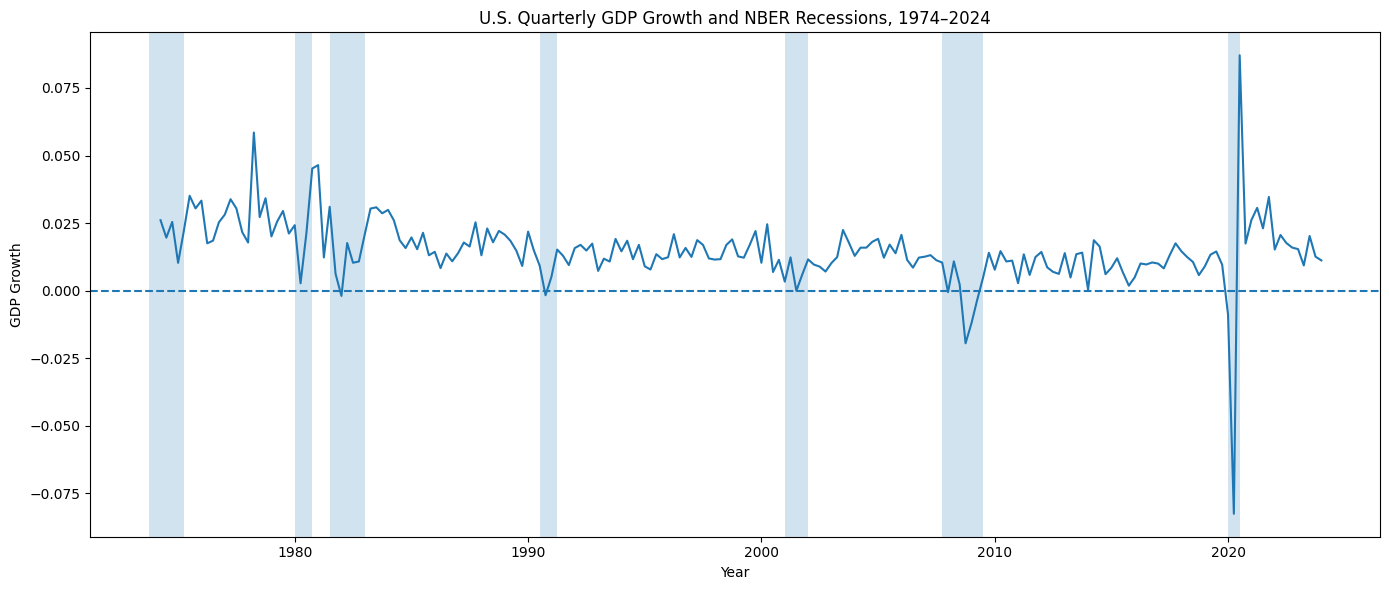

In [349]:
# Convert quarter to timestamp for plotting
df_plot = df_economy.copy()
df_plot['date'] = pd.PeriodIndex(
    df_plot['year-quarter'],
    freq='Q'
).to_timestamp()

# Official NBER recession periods
nber_recessions = [
    ('1973Q4', '1975Q1'),
    ('1980Q1', '1980Q3'),
    ('1981Q3', '1982Q4'),
    ('1990Q3', '1991Q1'),
    ('2001Q1', '2001Q4'),
    ('2007Q4', '2009Q2'),
    ('2020Q1', '2020Q2')
]

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    df_plot['date'],
    df_plot['gdp_growth'],
    label='Quarterly GDP Growth'
)

ax.axhline(0, linestyle='--')

# Add NBER recession shading
for start, end in nber_recessions:
    start_date = pd.Period(start, freq='Q').start_time
    end_date = pd.Period(end, freq='Q').end_time
    ax.axvspan(start_date, end_date, alpha=0.2)

ax.set_title('U.S. Quarterly GDP Growth and NBER Recessions, 1974–2024')
ax.set_xlabel('Year')
ax.set_ylabel('GDP Growth')

plt.tight_layout()
plt.show()

#### Unemployment

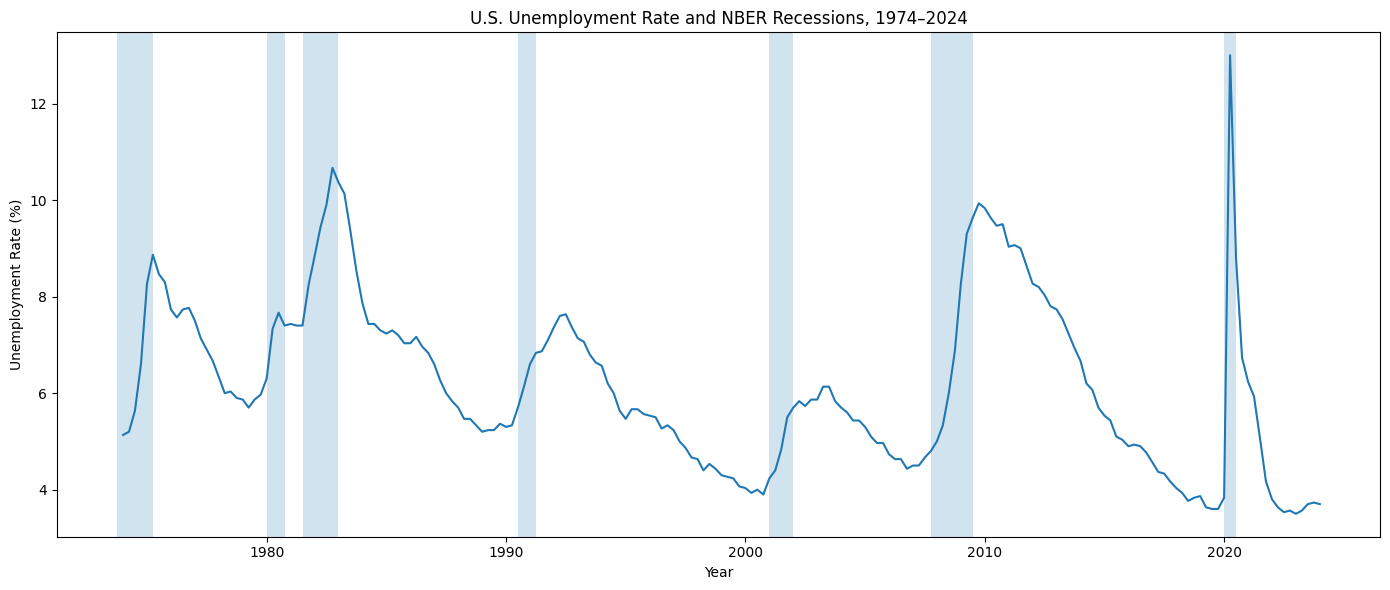

In [350]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    df_plot['date'],
    df_plot['unemployment_rate'],
    label='Unemployment Rate'
)

# Add NBER recession shading
for start, end in nber_recessions:
    start_date = pd.Period(start, freq='Q').start_time
    end_date = pd.Period(end, freq='Q').end_time
    ax.axvspan(start_date, end_date, alpha=0.2)

ax.set_title('U.S. Unemployment Rate and NBER Recessions, 1974–2024')
ax.set_xlabel('Year')
ax.set_ylabel('Unemployment Rate (%)')

plt.tight_layout()
plt.show()

### Table

In [351]:
recession_summary = pd.DataFrame({
    'recession': [
        '1973–1975',
        '1980',
        '1981–1982',
        '1990–1991',
        '2001',
        '2007–2009',
        '2020'
    ],
    'peak': [
        '1973Q4',
        '1980Q1',
        '1981Q3',
        '1990Q3',
        '2001Q1',
        '2007Q4',
        '2020Q1'
    ],
    'trough': [
        '1975Q1',
        '1980Q3',
        '1982Q4',
        '1991Q1',
        '2001Q4',
        '2009Q2',
        '2020Q2'
    ]
})

recession_summary

,recession,peak,trough
0,1973–1975,1973Q4,1975Q1
1,1980,1980Q1,1980Q3
2,1981–1982,1981Q3,1982Q4
3,1990–1991,1990Q3,1991Q1
4,2001,2001Q1,2001Q4
5,2007–2009,2007Q4,2009Q2
6,2020,2020Q1,2020Q2


| Recession | NBER Period | GDP Evidence | Labor Market Evidence | Main Historical Events / Economic Mechanism |
|---|---|---|---|---|
| 1973–1975 | 1973Q4–1975Q1 | A prolonged slowdown in economic activity accompanied by several quarters of relatively weak GDP growth. | Unemployment rose substantially during the downturn and remained elevated during the early recovery. | The 1973 oil shock increased energy costs and contributed to inflation and weaker economic activity. The downturn also interacted with monetary tightening and weakening aggregate demand. |
| 1980 | 1980Q1–1980Q3 | A short but noticeable contraction in economic activity. | Unemployment increased during the recession. | The Federal Reserve tightened monetary policy to combat high inflation, contributing to weaker aggregate demand and economic activity. |
| 1981–1982 | 1981Q3–1982Q4 | One of the more prolonged contractions in the post-1970 period, with particularly weak GDP growth around the trough. | Unemployment increased sharply and reached historically high levels during the downturn. | The Federal Reserve, under Paul Volcker, maintained highly restrictive monetary policy to reduce persistent inflation. The resulting contraction in aggregate demand contributed to the recession. |
| 1990–1991 | 1990Q3–1991Q1 | A relatively moderate contraction compared with the early-1980s and 2007–09 recessions. | Unemployment increased during and after the recession. | The recession was associated with the 1990 oil-price shock following Iraq's invasion of Kuwait, alongside weakening consumption, investment, and financial conditions. |
| 2001 | 2001Q1–2001Q4 | GDP growth weakened substantially, although the contraction was relatively mild compared with later recessions. | Unemployment increased gradually as labor-market conditions deteriorated. | The bursting of the dot-com bubble, declining business investment, and the September 11 attacks contributed to weaker aggregate demand and investment. |
| 2007–2009 | 2007Q4–2009Q2 | The data show a severe and prolonged deterioration in economic activity, including the sharp contractions observed in 2008–09. | Unemployment rose substantially, reaching very high levels during the recovery from the recession. | The collapse of the U.S. housing market triggered severe financial stress, credit contraction, and a major decline in consumption and investment. The downturn became a broad financial and demand shock. |
| 2020 | 2020Q1–2020Q2 | The sharpest quarterly contraction in the dataset occurred in 2020Q2, with GDP growth falling to approximately −8.3%. | Unemployment experienced an exceptional increase, reaching approximately 13% in 2020Q2. | The COVID-19 pandemic caused widespread shutdowns and disruptions to production, while uncertainty and restrictions also sharply reduced consumption and investment. The recession therefore combined major supply and demand shocks. |

# Question 2 — GDP Growth, Unemployment, and Inflation

## What are the relationships between GDP growth, unemployment, and inflation (CPI growth) in the U.S. economy?

## 1. Economic Framework

### Economic Growth

Economic growth refers to the increase in an economy's real output over time. In this analysis, economic growth is measured using quarterly real GDP growth.

### Unemployment

An unemployed person is someone who is without a job, available to work, and actively searching for work within the relevant period.

The unemployment rate is calculated as:

**Unemployment Rate = Unemployed / Labor Force × 100**

For the analysis of Okun's Law, the change in the unemployment rate is used rather than its level.

### Inflation

Inflation is the rate at which the general price level of goods and services increases over time. In this analysis, inflation is measured using quarterly CPI growth.

---

## 2. Theoretical Relationships

### Okun's Law

Okun's Law describes an empirical relationship between economic activity and unemployment. In general, stronger economic growth is associated with declines in unemployment, while weaker or negative growth is associated with increases in unemployment.

The relationship is therefore expected to be negative between GDP growth and changes in the unemployment rate.

### Phillips Curve

The Phillips Curve describes a relationship between inflation and labor-market slack. In its modern expectations-augmented form, inflation depends not only on unemployment but also on expected inflation and other economic conditions.

Therefore, a simple relationship between the unemployment rate and inflation may not fully capture the theoretical Phillips Curve.

### Aggregate Demand and Aggregate Supply

The Aggregate Demand–Aggregate Supply framework provides a broader explanation for the joint behavior of output, unemployment, and inflation.

For example, a positive demand shock can increase both output and inflation in the short run, producing a positive relationship between GDP growth and inflation.

In contrast, supply shocks can reduce output while increasing prices, meaning that the observed relationship between growth and inflation may vary across different periods.

---

## 3. Empirical Analysis

### GDP Growth and Unemployment

The data show a strong negative relationship between GDP growth and changes in the unemployment rate.

The correlation coefficient is **-0.730**, indicating that quarters with stronger GDP growth tend to be associated with declines in unemployment, while weaker economic growth tends to coincide with increases in unemployment.

This pattern is consistent with the expected relationship described by Okun's Law.

### GDP Growth and Inflation

GDP growth and CPI growth have a moderate positive correlation of **0.510**.

This indicates that periods of stronger economic growth tend, on average, to coincide with higher inflation.

However, this relationship should not be interpreted as a direct causal effect. Different types of economic shocks can affect output and inflation in different ways.

### Unemployment and Inflation

The correlation between the unemployment rate and CPI growth is approximately **0.008**, indicating virtually no simple linear relationship in the full sample.

This finding does not imply that the Phillips Curve is absent. Rather, it suggests that a simple level-to-level relationship between unemployment and inflation does not adequately describe the relationship over the entire 1974–2024 period.

---

## 4. Statistical Analysis

### Correlation Analysis

The correlation results are summarized below:

| Relationship                       | Correlation |
| ---------------------------------- | ----------: |
| GDP Growth vs. Unemployment Change |      -0.730 |
| GDP Growth vs. CPI Growth          |       0.510 |
| Unemployment Rate vs. CPI Growth   |       0.008 |

The strongest relationship is between GDP growth and changes in unemployment, while the unemployment–inflation relationship is essentially zero in the full sample.

### Regression Analysis

Three simple OLS regression models were estimated:

**Model 1 — Okun's Law**

$$
\Delta U_t = \beta_0 + \beta_1 GDPGrowth_t + \epsilon_t
$$

**Model 2 — GDP Growth and Inflation**

$$
CPIGrowth_t = \beta_0 + \beta_1 GDPGrowth_t + \epsilon_t
$$

**Model 3 — Unemployment and Inflation**

$$
CPIGrowth_t = \beta_0 + \beta_1 UnemploymentRate_t + \epsilon_t
$$

The main OLS results are:

| Model                            | Coefficient |    R² | p-value |
| -------------------------------- | ----------: | ----: | ------: |
| GDP Growth → Unemployment Change |     -46.267 | 0.532 | < 0.001 |
| GDP Growth → CPI Growth          |       0.322 | 0.261 | < 0.001 |
| Unemployment Rate → CPI Growth   |     0.00004 | 0.000 |   0.911 |

The Okun model explains approximately **53.2%** of the variation in quarterly changes in unemployment.

The GDP–CPI model explains approximately **26.1%** of the variation in quarterly CPI growth.

The unemployment–inflation model has virtually no explanatory power in this simple specification.

### Interpretation of Regression Results

The coefficient in the Okun model is approximately **-46.27**. Because GDP growth is expressed as a decimal, a one-percentage-point increase in quarterly GDP growth is associated with approximately a **0.46 percentage-point larger decline in the unemployment rate**, holding the specification constant.

The GDP–CPI coefficient is approximately **0.322**. Thus, a one-percentage-point increase in quarterly GDP growth is associated with approximately a **0.32 percentage-point increase in quarterly CPI growth** in this simple model.

The unemployment coefficient in the Phillips specification is very close to zero and statistically insignificant. Therefore, this model provides no evidence of a simple linear relationship between the unemployment rate and CPI growth over the full sample.

---

## 5. Regression Diagnostics and Robust Inference

Because the dataset consists of quarterly macroeconomic time-series observations, residual dependence and heteroskedasticity were examined.

### Serial Correlation

The Breusch–Godfrey test indicates statistically significant serial correlation in all three models.

This is consistent with the relatively low Durbin–Watson statistics, particularly for the GDP–CPI and Phillips models.

### Heteroskedasticity

The Breusch–Pagan test provides evidence of heteroskedasticity in the Okun model.

However, there is no statistically significant evidence of heteroskedasticity in the GDP–CPI or Phillips models.

### HAC Standard Errors

To obtain more reliable statistical inference in the presence of autocorrelation and possible heteroskedasticity, HAC (Newey–West) standard errors with four lags were used.

The HAC-adjusted results are:

| Model                            | Coefficient | HAC p-value | Conclusion                    |
| -------------------------------- | ----------: | ----------: | ----------------------------- |
| GDP Growth → Unemployment Change |     -46.267 |       0.004 | Statistically significant     |
| GDP Growth → CPI Growth          |       0.322 |       0.001 | Statistically significant     |
| Unemployment Rate → CPI Growth   |     0.00004 |       0.933 | Not statistically significant |

The HAC results do not change the substantive conclusions of the three models. The negative GDP growth–unemployment relationship and the positive GDP growth–inflation relationship remain statistically significant, while the simple unemployment–inflation relationship remains insignificant.

---

## 6. Limitations

### Correlation vs. Causation

The correlations and regressions presented here describe statistical associations and do not establish causal relationships.

For example, higher GDP growth and higher inflation may occur together because of common demand shocks rather than because GDP growth directly causes inflation.

Similarly, unemployment and inflation are influenced by many factors beyond the variables included in these simple regressions.

### Time Variation

The relationships between GDP growth, unemployment, and inflation may change across different historical periods.

The U.S. economy experienced major structural and policy changes between 1974 and 2024, including different monetary policy regimes, productivity trends, supply shocks, financial crises, and the COVID-19 pandemic.

Therefore, full-sample estimates may conceal important differences across sub-periods.

### Model Specification

The regressions use simple bivariate specifications. They do not explicitly control for factors such as monetary policy, oil and energy prices, productivity, inflation expectations, or major supply shocks.

The simple Phillips Curve specification is particularly limited because the modern Phillips Curve incorporates expected inflation and measures of economic slack rather than relying only on the unemployment rate.

---

## 7. Economic Interpretation

The empirical results provide three important findings.

First, the data show a strong and statistically significant negative relationship between GDP growth and changes in unemployment. This is consistent with Okun's Law and indicates that economic expansions are generally associated with improvements in labor-market conditions.

Second, GDP growth and CPI growth display a moderate positive relationship. This is consistent with the possibility that stronger aggregate demand can increase both economic activity and inflation. However, the relationship is not necessarily causal and can be affected by the nature of economic shocks.

Third, the full-sample data do not reveal a simple linear relationship between the unemployment rate and CPI growth. This does not invalidate the Phillips Curve as an economic concept. Instead, it suggests that the relationship is more complex and may depend on inflation expectations, the natural rate of unemployment, supply shocks, monetary policy, and the historical period considered.

Overall, the results suggest that the relationships among growth, unemployment, and inflation are economically meaningful but cannot be fully described by simple bivariate relationships.

---

## 8. Conclusion

The analysis shows that GDP growth, unemployment, and inflation are related in different ways.

The strongest relationship in the sample is the negative association between GDP growth and changes in unemployment, consistent with Okun's Law. GDP growth also has a moderate positive association with CPI growth.

In contrast, the full-sample relationship between unemployment and CPI growth is essentially zero and statistically insignificant in the simple specification used here.

The diagnostic analysis also demonstrates the importance of accounting for time-series characteristics. All three models exhibit serial correlation, and the Okun model also shows evidence of heteroskedasticity. HAC standard errors were therefore used to obtain more reliable inference.

These findings provide a useful empirical overview of U.S. macroeconomic relationships from 1974 to 2024, while highlighting the limitations of simple models and the importance of considering changes across historical periods.


### Q2 Data audit

In [352]:
q2_df = df_economy[
    [
        "year-quarter",
        "gdp_growth",
        "unemployment_rate",
        "unemployment_change",
        "cpi_growth"
    ]
].copy()

In [353]:
q2_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year-quarter         201 non-null    str    
 1   gdp_growth           200 non-null    float64
 2   unemployment_rate    201 non-null    float64
 3   unemployment_change  200 non-null    float64
 4   cpi_growth           200 non-null    float64
dtypes: float64(4), str(1)
memory usage: 9.2 KB


In [354]:
q2_df.isna().sum()

year-quarter           0
gdp_growth             1
unemployment_rate      0
unemployment_change    1
cpi_growth             1
dtype: int64

In [355]:
q2_df.describe()

,gdp_growth,unemployment_rate,unemployment_change,cpi_growth
count,200.0000,201.0000,200.0000,200.0000
mean,0.0149,6.1768,-0.0072,0.0095
std,0.0127,1.7483,0.8054,0.0080
min,-0.0826,3.5000,-4.2000,-0.0229
25%,0.0103,4.9000,-0.2000,0.0053
50%,0.0138,5.8667,-0.0667,0.0079
75%,0.0191,7.3333,0.0667,0.0115
max,0.0871,13.0000,9.1667,0.0395


In [356]:
q2_df.head()

,year-quarter,gdp_growth,unemployment_rate,unemployment_change,cpi_growth
0,1974Q1,NaN,5.1333,NaN,NaN
1,1974Q2,0.0261,5.2000,0.0667,0.0268
2,1974Q3,0.0196,5.6333,0.4333,0.0281
3,1974Q4,0.0254,6.6000,0.9667,0.0307
4,1975Q1,0.0103,8.2667,1.6667,0.0214


### Visual exploration

In [357]:
q2_plot = q2_df.dropna().copy()

q2_plot.shape

(200, 5)

#### GDP growth vs Unemployment change

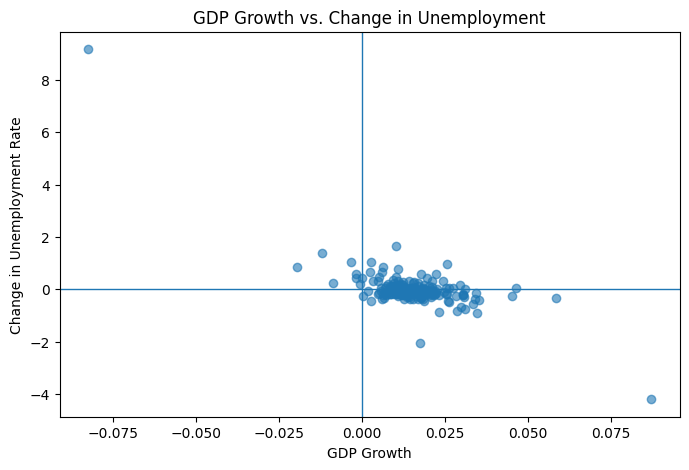

In [358]:
plt.figure(figsize=(8, 5))

plt.scatter(
    q2_plot["gdp_growth"],
    q2_plot["unemployment_change"],
    alpha=0.6
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel("GDP Growth")
plt.ylabel("Change in Unemployment Rate")
plt.title("GDP Growth vs. Change in Unemployment")

plt.show()

#### GDP growth vs CPI growth

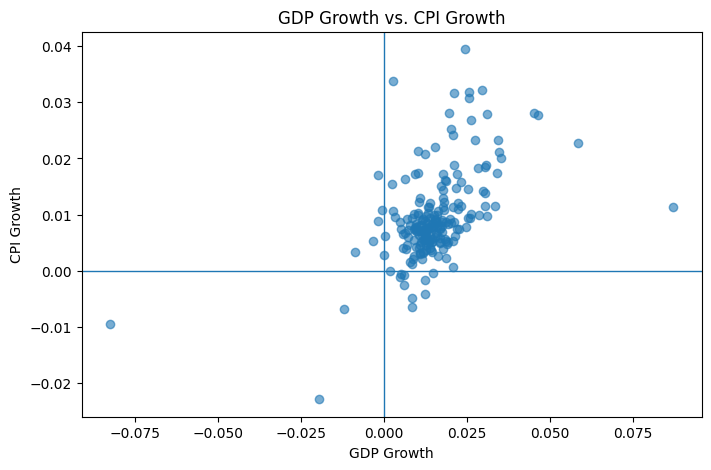

In [359]:
plt.figure(figsize=(8, 5))

plt.scatter(
    q2_plot["gdp_growth"],
    q2_plot["cpi_growth"],
    alpha=0.6
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel("GDP Growth")
plt.ylabel("CPI Growth")
plt.title("GDP Growth vs. CPI Growth")

plt.show()

#### Unemployment vs CPI growth

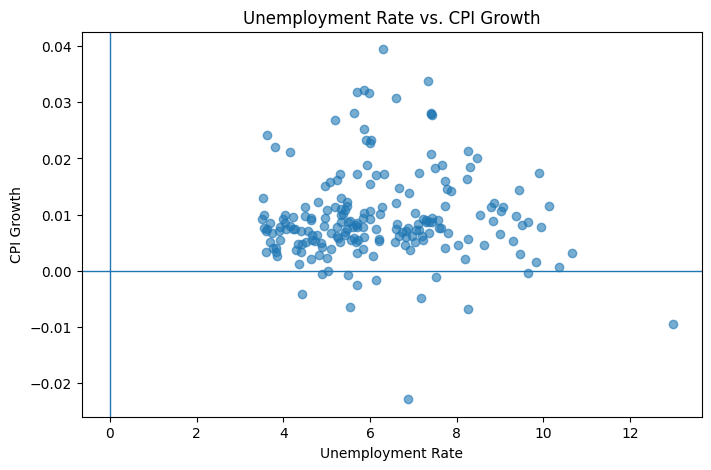

In [360]:
plt.figure(figsize=(8, 5))

plt.scatter(
    q2_plot["unemployment_rate"],
    q2_plot["cpi_growth"],
    alpha=0.6
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel("Unemployment Rate")
plt.ylabel("CPI Growth")
plt.title("Unemployment Rate vs. CPI Growth")

plt.show()

#### GDP growth + Unemployment change(time based)

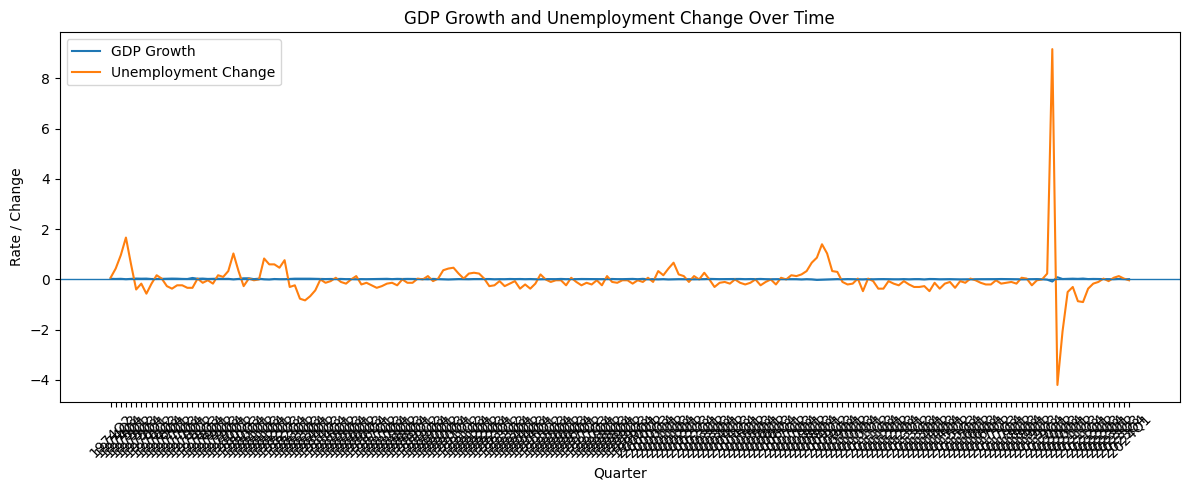

In [361]:
plt.figure(figsize=(12, 5))

plt.plot(
    q2_plot["year-quarter"],
    q2_plot["gdp_growth"],
    label="GDP Growth"
)

plt.plot(
    q2_plot["year-quarter"],
    q2_plot["unemployment_change"],
    label="Unemployment Change"
)

plt.axhline(0, linewidth=1)

plt.xlabel("Quarter")
plt.ylabel("Rate / Change")
plt.title("GDP Growth and Unemployment Change Over Time")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

#### GDP growth + CPI growth (time based)

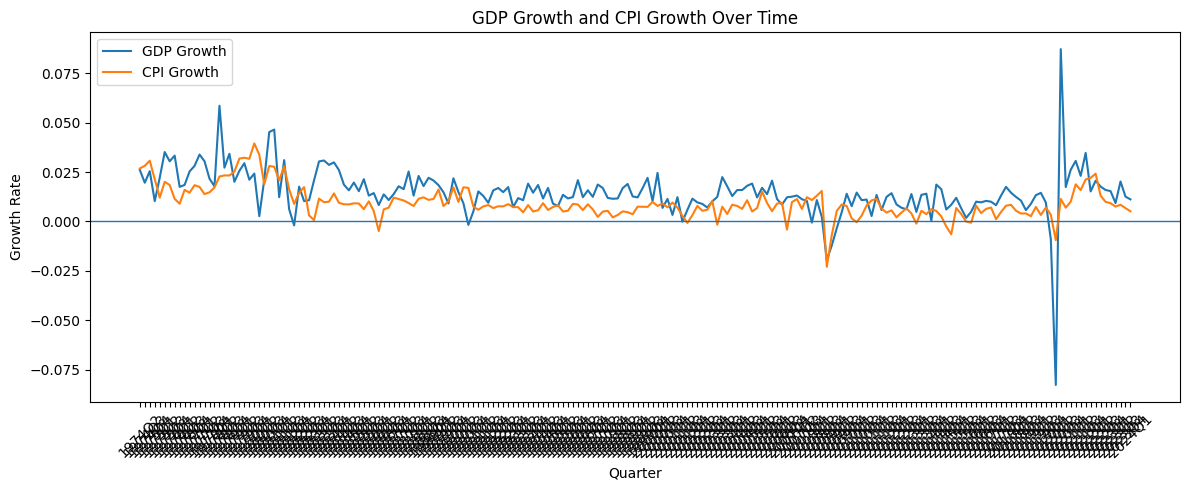

In [362]:
plt.figure(figsize=(12, 5))

plt.plot(
    q2_plot["year-quarter"],
    q2_plot["gdp_growth"],
    label="GDP Growth"
)

plt.plot(
    q2_plot["year-quarter"],
    q2_plot["cpi_growth"],
    label="CPI Growth"
)

plt.axhline(0, linewidth=1)

plt.xlabel("Quarter")
plt.ylabel("Growth Rate")
plt.title("GDP Growth and CPI Growth Over Time")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### correlation analysis

In [363]:
correlation_matrix = q2_plot[
    [
        "gdp_growth",
        "unemployment_rate",
        "unemployment_change",
        "cpi_growth"
    ]
].corr()

correlation_matrix

,gdp_growth,unemployment_rate,unemployment_change,cpi_growth
gdp_growth,1.0000,-0.0529,-0.7297,0.5105
unemployment_rate,-0.0529,1.0000,0.2390,0.0080
unemployment_change,-0.7297,0.2390,1.0000,-0.1136
cpi_growth,0.5105,0.0080,-0.1136,1.0000


In [364]:
corr_gdp_unemp_change = q2_plot[
    ["gdp_growth", "unemployment_change"]
].corr().iloc[0, 1]

corr_gdp_cpi = q2_plot[
    ["gdp_growth", "cpi_growth"]
].corr().iloc[0, 1]

corr_unemp_cpi = q2_plot[
    ["unemployment_rate", "cpi_growth"]
].corr().iloc[0, 1]

print("GDP Growth vs. Unemployment Change:", corr_gdp_unemp_change)
print("GDP Growth vs. CPI Growth:", corr_gdp_cpi)
print("Unemployment Rate vs. CPI Growth:", corr_unemp_cpi)

GDP Growth vs. Unemployment Change: -0.7296624643851951
GDP Growth vs. CPI Growth: 0.5104593974249086
Unemployment Rate vs. CPI Growth: 0.007973146199395363


In [365]:
correlation_results = pd.DataFrame({
    "Relationship": [
        "GDP Growth vs. Unemployment Change",
        "GDP Growth vs. CPI Growth",
        "Unemployment Rate vs. CPI Growth"
    ],
    "Correlation": [
        corr_gdp_unemp_change,
        corr_gdp_cpi,
        corr_unemp_cpi
    ]
})

correlation_results["Correlation"] = (
    correlation_results["Correlation"].round(3)
)

correlation_results

,Relationship,Correlation
0,GDP Growth vs. Unemployment Change,-0.7300
1,GDP Growth vs. CPI Growth,0.5100
2,Unemployment Rate vs. CPI Growth,0.0080


### regression analysis

#### Okun's law

In [366]:
X = q2_plot["gdp_growth"]
y = q2_plot["unemployment_change"]

X = sm.add_constant(X)

model_okun = sm.OLS(y, X).fit()

print(model_okun.summary())

                             OLS Regression Results                            
Dep. Variable:     unemployment_change   R-squared:                       0.532
Model:                             OLS   Adj. R-squared:                  0.530
Method:                  Least Squares   F-statistic:                     225.4
Date:                 Fri, 18 Sep 2026   Prob (F-statistic):           1.60e-34
Time:                         20:07:56   Log-Likelihood:                -163.98
No. Observations:                  200   AIC:                             332.0
Df Residuals:                      198   BIC:                             338.6
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6822      0.060     11.32

#### Inflation & GDP growth

In [367]:
X = q2_plot["gdp_growth"]
y = q2_plot["cpi_growth"]

X = sm.add_constant(X)

model_gdp_cpi = sm.OLS(y, X).fit()

print(model_gdp_cpi.summary())

                            OLS Regression Results                            
Dep. Variable:             cpi_growth   R-squared:                       0.261
Model:                            OLS   Adj. R-squared:                  0.257
Method:                 Least Squares   F-statistic:                     69.77
Date:                Fri, 18 Sep 2026   Prob (F-statistic):           1.15e-14
Time:                        20:07:56   Log-Likelihood:                 712.45
No. Observations:                 200   AIC:                            -1421.
Df Residuals:                     198   BIC:                            -1414.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0047      0.001      6.210      0.0

#### Phillips curve

In [368]:
X = q2_plot["unemployment_rate"]
y = q2_plot["cpi_growth"]

X = sm.add_constant(X)

model_phillips = sm.OLS(y, X).fit()

print(model_phillips.summary())

                            OLS Regression Results                            
Dep. Variable:             cpi_growth   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.005
Method:                 Least Squares   F-statistic:                   0.01259
Date:                Fri, 18 Sep 2026   Prob (F-statistic):              0.911
Time:                        20:07:56   Log-Likelihood:                 682.27
No. Observations:                 200   AIC:                            -1361.
Df Residuals:                     198   BIC:                            -1354.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.0092      0.00

### Regression diagnosis & robust inference

In [369]:
bg_okun = acorr_breusch_godfrey(model_okun, nlags=4)
bg_gdp_cpi = acorr_breusch_godfrey(model_gdp_cpi, nlags=4)
bg_phillips = acorr_breusch_godfrey(model_phillips, nlags=4)

print("Okun:", bg_okun)
print("GDP-CPI:", bg_gdp_cpi)
print("Phillips:", bg_phillips)

Okun: (np.float64(38.242829658859435), np.float64(9.984666606099172e-08), 11.466429800564745, 2.243629697390691e-08)
GDP-CPI: (np.float64(80.3762676626774), np.float64(1.4497307617431955e-16), 32.58758864543144, 8.917498925329682e-21)
Phillips: (np.float64(111.49725423375172), np.float64(3.4884638659057785e-23), 61.1011193327207, 2.488045846190568e-33)


In [370]:
bp_okun = het_breuschpagan(
    model_okun.resid,
    model_okun.model.exog
)

bp_gdp_cpi = het_breuschpagan(
    model_gdp_cpi.resid,
    model_gdp_cpi.model.exog
)

bp_phillips = het_breuschpagan(
    model_phillips.resid,
    model_phillips.model.exog
)

print("Okun:", bp_okun)
print("GDP-CPI:", bp_gdp_cpi)
print("Phillips:", bp_phillips)

Okun: (np.float64(41.945261488263895), np.float64(9.386457195128311e-11), np.float64(52.546110625209536), np.float64(9.212454344282287e-12))
GDP-CPI: (np.float64(0.8457067413071284), np.float64(0.35776972391611594), np.float64(0.8408050463732809), np.float64(0.3602821453479903))
Phillips: (np.float64(2.0330662567836777), np.float64(0.15390981883129162), np.float64(2.0334058381957565), np.float64(0.15545014642195068))


In [371]:
hac_okun = model_okun.get_robustcov_results(
    cov_type="HAC",
    maxlags=4
)

hac_gdp_cpi = model_gdp_cpi.get_robustcov_results(
    cov_type="HAC",
    maxlags=4
)

hac_phillips = model_phillips.get_robustcov_results(
    cov_type="HAC",
    maxlags=4
)
print("=== Okun Model — HAC ===")
print(hac_okun.summary())

print("\n=== GDP-CPI Model — HAC ===")
print(hac_gdp_cpi.summary())

print("\n=== Phillips Model — HAC ===")
print(hac_phillips.summary())

=== Okun Model — HAC ===
                             OLS Regression Results                            
Dep. Variable:     unemployment_change   R-squared:                       0.532
Model:                             OLS   Adj. R-squared:                  0.530
Method:                  Least Squares   F-statistic:                     8.432
Date:                 Fri, 18 Sep 2026   Prob (F-statistic):            0.00411
Time:                         20:07:56   Log-Likelihood:                -163.98
No. Observations:                  200   AIC:                             332.0
Df Residuals:                      198   BIC:                             338.6
Df Model:                            1                                         
Covariance Type:                   HAC                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.

# Question 3 — The COVID-19 Economic Shock

## How did the COVID-19 shock affect U.S. economic activity, unemployment, and inflation?

## 1. Economic Framework

### Demand Shocks

A demand shock is an unexpected change in aggregate spending that shifts the aggregate demand (AD) curve, generally moving output and the price level in the same direction.

### Supply Shocks

A supply shock is an unexpected disturbance to production capacity, production costs, or the availability of inputs. A negative supply shock generally reduces output while increasing price pressures in the short run.

### Labor-Market Shocks

A labor-market shock is a sudden disturbance to employment, unemployment, job separations, labor-force participation, or the matching process between workers and jobs.

The COVID-19 pandemic generated an unusual combination of these three types of shocks. Lockdowns, social distancing, business closures, and disruptions to production affected aggregate supply, while uncertainty, restrictions on economic activity, and changes in household and business spending reduced aggregate demand. At the same time, the labor market experienced an exceptionally large increase in unemployment.

---

## 2. The COVID-19 Shock

### Initial Economic Disruption

The COVID-19 pandemic produced a sudden disruption to U.S. economic activity in early 2020. Measures introduced to contain the spread of the virus restricted production and economic activity, while households and firms simultaneously reduced or postponed spending.

The result was a combination of supply-side and demand-side disruptions. The initial collapse in economic activity was accompanied by a sharp deterioration in labor-market conditions and a decline in inflation.

The economic sequence can be summarized as:

**COVID-19 shock → supply disruption + demand collapse → GDP decline + unemployment increase + initial inflation decline**

### Output Shock

The COVID-19 shock generated an exceptionally sharp contraction in U.S. economic output. Real GDP growth became strongly negative in the second quarter of 2020, reflecting the sudden reduction in economic activity.

The contraction was followed by a rapid rebound as restrictions were eased and economic activity resumed.

### Labor-Market Shock

The labor market experienced an unusually large shock. Unemployment increased sharply during the initial phase of the pandemic, reflecting the sudden reduction in economic activity and employment opportunities.

The subsequent decline in unemployment was rapid at first, but the labor market took considerably longer than GDP to return to approximately its pre-pandemic level.

### Inflation Shock

Inflation followed a different trajectory from output and unemployment.

During the initial shock, the collapse in economic activity and demand contributed to weaker price pressures. Later, as economic activity reopened, demand recovered rapidly while supply remained constrained. Supply bottlenecks, energy and commodity shocks, and labor-market frictions contributed to stronger inflationary pressures.

Therefore, the post-pandemic inflation episode should not be interpreted as a simple continuation of the initial COVID shock. It reflected a changi


### Q3 Data audit

In [372]:
df_economy.shape

(201, 25)

In [373]:
df_economy.columns.to_list()

['year',
 'quarter',
 'year-quarter',
 'gdp',
 'cpi',
 'unemployment_rate',
 'gdp_growth',
 'cpi_growth',
 'unemployment_change',
 'gdp_yoy',
 'cpi_yoy',
 'unemployment_yoy_change',
 'gdp_rolling_mean_4q',
 'cpi_rolling_mean_4q',
 'unemployment_rolling_mean_4q',
 'gdp_volatility_4q',
 'cpi_volatility_4q',
 'unemployment_volatility_4q',
 'gdp_growth_lag1',
 'gdp_growth_lag2',
 'cpi_growth_lag1',
 'unemployment_change_lag1',
 'covid_flag',
 'recession_flag',
 'high_growth_flag']

In [374]:
covid_gdp = df_economy[["year-quarter","gdp", "gdp_growth", "cpi", "cpi_growth",
             "unemployment_rate", "unemployment_change", "covid_flag"]].query(
                 'covid_flag == True')
covid_gdp

,year-quarter,gdp,gdp_growth,cpi,cpi_growth,unemployment_rate,unemployment_change,covid_flag
184,2020Q1,21706.5130,-0.0089,258.7673,0.0034,3.8333,0.2333,True
185,2020Q2,19913.1430,-0.0826,256.3260,-0.0094,13.0000,9.1667,True
186,2020Q3,21647.6400,0.0871,259.2417,0.0114,8.8000,-4.2000,True
187,2020Q4,22024.5020,0.0174,261.0497,0.0070,6.7333,-2.0667,True
188,2021Q1,22600.1850,0.0261,263.6703,0.0100,6.2333,-0.5000,True


### GDP analysis

In [375]:
covid_period = df_economy[
    df_economy["year-quarter"].isin(
        ["2020Q1", "2020Q2", "2020Q3", "2020Q4", "2021Q1"]
    )
]

covid_trough = covid_period.loc[
    covid_period["gdp"].idxmin()
]

covid_trough

year                                 2020
quarter                                 2
year-quarter                       2020Q2
gdp                            19913.1430
cpi                              256.3260
unemployment_rate                 13.0000
gdp_growth                        -0.0826
cpi_growth                        -0.0094
unemployment_change                9.1667
gdp_yoy                           -0.0688
cpi_yoy                            0.0042
unemployment_yoy_change            9.3667
gdp_rolling_mean_4q               -0.0169
cpi_rolling_mean_4q                0.0011
unemployment_rolling_mean_4q       6.0083
gdp_volatility_4q                  0.0450
cpi_volatility_4q                  0.0072
unemployment_volatility_4q         4.5515
gdp_growth_lag1                   -0.0089
gdp_growth_lag2                    0.0096
cpi_growth_lag1                    0.0034
unemployment_change_lag1           0.2333
covid_flag                           True
recession_flag                    

In [376]:
pre_covid_gdp = df_economy.loc[
    df_economy["year-quarter"] == "2019Q4", "gdp"
].iloc[0]

covid_trough_gdp = covid_trough["gdp"]

gdp_drop_pct = (
    (covid_trough_gdp - pre_covid_gdp)
    / pre_covid_gdp
) * 100

gdp_drop_pct

np.float64(-9.082328458218484)

### GDP growth plot

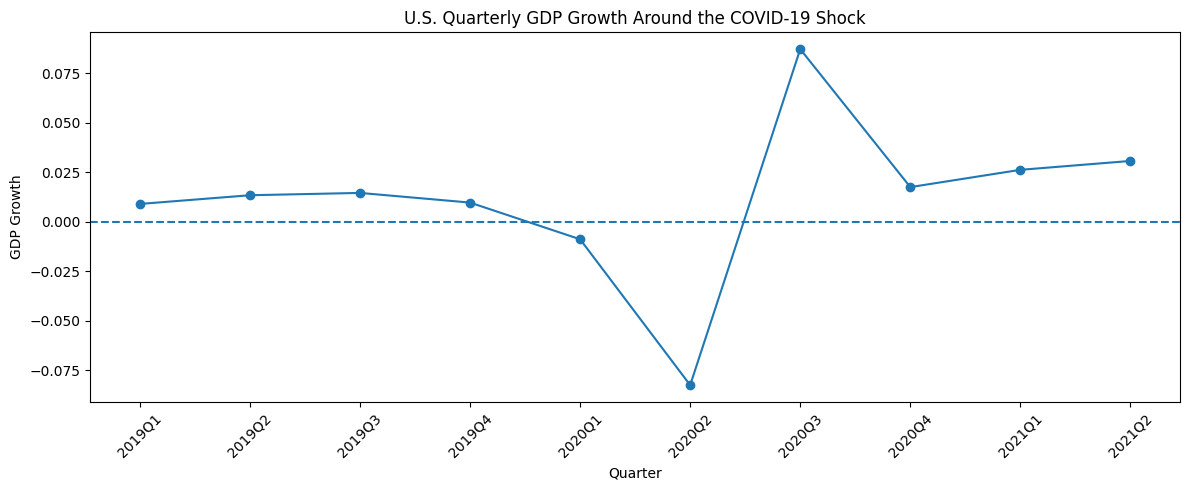

In [377]:
covid_gdp = df_economy[
    ["year-quarter", "gdp_growth"]
].query(
    "`year-quarter` >= '2019Q1' and `year-quarter` <= '2021Q2'"
)

plt.figure(figsize=(12, 5))

plt.plot(
    covid_gdp["year-quarter"],
    covid_gdp["gdp_growth"],
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.title("U.S. Quarterly GDP Growth Around the COVID-19 Shock")
plt.xlabel("Quarter")
plt.ylabel("GDP Growth")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### GDP recovery

In [378]:
gdp_recovery = df_economy[
    ["year-quarter", "gdp"]
].query(
    "`year-quarter` >= '2019Q4' and `year-quarter` <= '2021Q2'"
)

gdp_recovery

,year-quarter,gdp
183,2019Q4,21902.3900
184,2020Q1,21706.5130
185,2020Q2,19913.1430
186,2020Q3,21647.6400
187,2020Q4,22024.5020
188,2021Q1,22600.1850
189,2021Q2,23292.3620


In [379]:
pre_covid_gdp = df_economy.loc[
    df_economy["year-quarter"] == "2019Q4", "gdp"
].iloc[0]

gdp_recovery["gdp_vs_pre_covid_pct"] = (
    (gdp_recovery["gdp"] - pre_covid_gdp)
    / pre_covid_gdp
) * 100

gdp_recovery

,year-quarter,gdp,gdp_vs_pre_covid_pct
183,2019Q4,21902.3900,0.0000
184,2020Q1,21706.5130,-0.8943
185,2020Q2,19913.1430,-9.0823
186,2020Q3,21647.6400,-1.1631
187,2020Q4,22024.5020,0.5575
188,2021Q1,22600.1850,3.1859
189,2021Q2,23292.3620,6.3462


### GDP pre covid

In [380]:
recovery_point = df_economy[
    (df_economy["year-quarter"] > "2020Q2") &
    (df_economy["gdp"] >= pre_covid_gdp)
]

recovery_point[["year-quarter", "gdp"]].head()

,year-quarter,gdp
187,2020Q4,22024.5020
188,2021Q1,22600.1850
189,2021Q2,23292.3620
190,2021Q3,23828.9730
191,2021Q4,24654.6030


### recovery plot

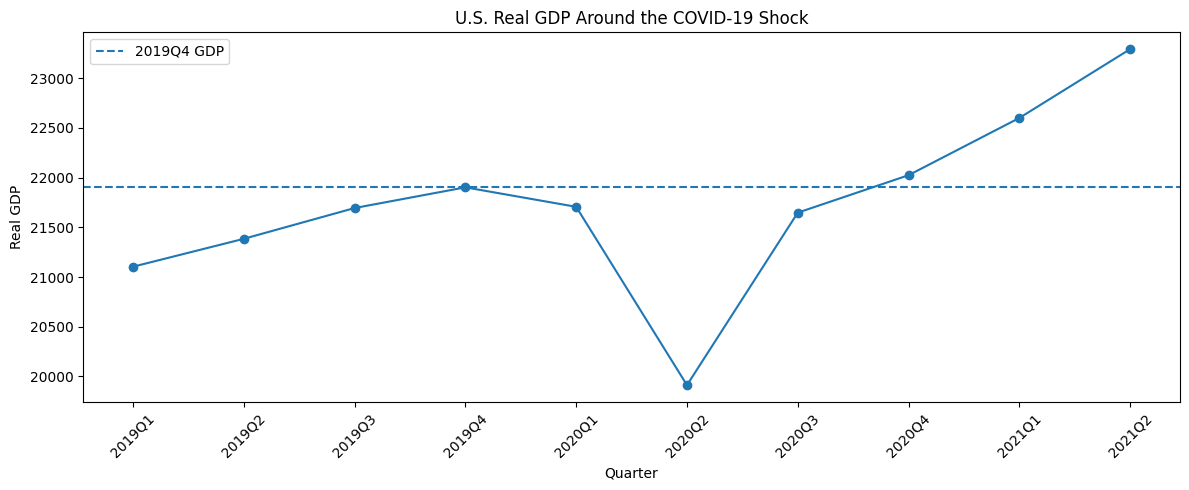

In [381]:
gdp_period = df_economy[
    ["year-quarter", "gdp"]
].query(
    "`year-quarter` >= '2019Q1' and `year-quarter` <= '2021Q2'"
)

plt.figure(figsize=(12, 5))

plt.plot(
    gdp_period["year-quarter"],
    gdp_period["gdp"],
    marker="o"
)

plt.axhline(
    pre_covid_gdp,
    linestyle="--",
    label="2019Q4 GDP"
)

plt.title("U.S. Real GDP Around the COVID-19 Shock")
plt.xlabel("Quarter")
plt.ylabel("Real GDP")

plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

###  Unemployment response

In [382]:
covid_unemployment = df_economy[
    ["year-quarter", "unemployment_rate", "unemployment_change", "covid_flag"]
].query("covid_flag == True")

covid_unemployment

,year-quarter,unemployment_rate,unemployment_change,covid_flag
184,2020Q1,3.8333,0.2333,True
185,2020Q2,13.0000,9.1667,True
186,2020Q3,8.8000,-4.2000,True
187,2020Q4,6.7333,-2.0667,True
188,2021Q1,6.2333,-0.5000,True


### Unemployment shock size

In [383]:
peak_unemployment = covid_unemployment.loc[
    covid_unemployment["unemployment_rate"].idxmax()
]

peak_unemployment

year-quarter           2020Q2
unemployment_rate     13.0000
unemployment_change    9.1667
covid_flag               True
Name: 185, dtype: object

In [384]:
pre_covid_unemployment = df_economy.loc[
    df_economy["year-quarter"] == "2019Q4",
    "unemployment_rate"
].iloc[0]

peak_unemployment_rate = peak_unemployment["unemployment_rate"]

unemployment_increase = (
    peak_unemployment_rate - pre_covid_unemployment
)

unemployment_increase

np.float64(9.4)

In [385]:
unemployment_relative_change = (
    (peak_unemployment_rate - pre_covid_unemployment)
    / pre_covid_unemployment
) * 100

unemployment_relative_change

np.float64(261.11111111111114)

### unemployment plot

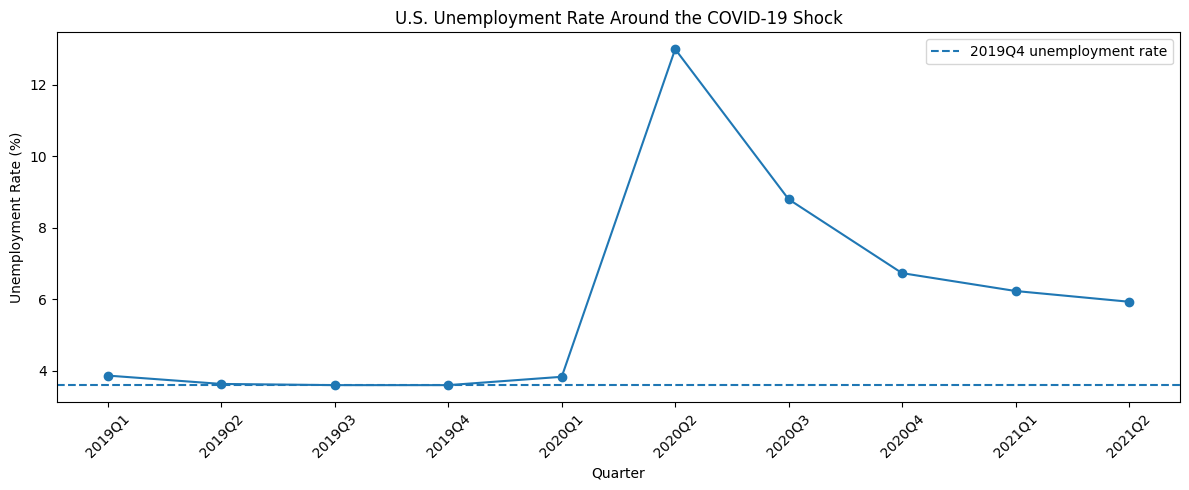

In [386]:
unemployment_period = df_economy[
    ["year-quarter", "unemployment_rate"]
].query(
    "`year-quarter` >= '2019Q1' and `year-quarter` <= '2021Q2'"
)

plt.figure(figsize=(12, 5))

plt.plot(
    unemployment_period["year-quarter"],
    unemployment_period["unemployment_rate"],
    marker="o"
)

plt.axhline(
    pre_covid_unemployment,
    linestyle="--",
    label="2019Q4 unemployment rate"
)

plt.title("U.S. Unemployment Rate Around the COVID-19 Shock")
plt.xlabel("Quarter")
plt.ylabel("Unemployment Rate (%)")

plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

### recovery speed

In [387]:
unemployment_recovery = df_economy[
    ["year-quarter", "unemployment_rate"]
].query(
    "`year-quarter` >= '2019Q4' and `year-quarter` <= '2021Q4'"
)

unemployment_recovery

,year-quarter,unemployment_rate
183,2019Q4,3.6000
184,2020Q1,3.8333
185,2020Q2,13.0000
186,2020Q3,8.8000
187,2020Q4,6.7333
188,2021Q1,6.2333
189,2021Q2,5.9333
190,2021Q3,5.0667
191,2021Q4,4.1667


In [388]:
unemployment_recovery["unemployment_vs_pre_covid"] = (
    unemployment_recovery["unemployment_rate"]
    - pre_covid_unemployment
)

unemployment_recovery

,year-quarter,unemployment_rate,unemployment_vs_pre_covid
183,2019Q4,3.6000,0.0000
184,2020Q1,3.8333,0.2333
185,2020Q2,13.0000,9.4000
186,2020Q3,8.8000,5.2000
187,2020Q4,6.7333,3.1333
188,2021Q1,6.2333,2.6333
189,2021Q2,5.9333,2.3333
190,2021Q3,5.0667,1.4667
191,2021Q4,4.1667,0.5667


### Unemployment recovery

In [389]:
unemployment_return = df_economy[
    (df_economy["year-quarter"] > "2020Q2") &
    (df_economy["unemployment_rate"] <= pre_covid_unemployment)
]

unemployment_return[
    ["year-quarter", "unemployment_rate"]
].head()

,year-quarter,unemployment_rate
194,2022Q3,3.5333
195,2022Q4,3.5667
196,2023Q1,3.5000
197,2023Q2,3.5667


### GDP vs Unemployment

In [390]:
covid_comparison = df_economy[
    ["year-quarter", "gdp", "gdp_growth",
     "unemployment_rate", "unemployment_change"]
].query(
    "`year-quarter` >= '2019Q4' and `year-quarter` <= '2021Q2'"
)

covid_comparison

,year-quarter,gdp,gdp_growth,unemployment_rate,unemployment_change
183,2019Q4,21902.3900,0.0096,3.6000,0.0000
184,2020Q1,21706.5130,-0.0089,3.8333,0.2333
185,2020Q2,19913.1430,-0.0826,13.0000,9.1667
186,2020Q3,21647.6400,0.0871,8.8000,-4.2000
187,2020Q4,22024.5020,0.0174,6.7333,-2.0667
188,2021Q1,22600.1850,0.0261,6.2333,-0.5000
189,2021Q2,23292.3620,0.0306,5.9333,-0.3000


### Unemployment change

In [391]:
max_unemployment_change = covid_unemployment.loc[
    covid_unemployment["unemployment_change"].idxmax()
]

max_unemployment_change

year-quarter           2020Q2
unemployment_rate     13.0000
unemployment_change    9.1667
covid_flag               True
Name: 185, dtype: object

In [392]:
unemployment_return[
    ["year-quarter", "unemployment_rate"]
].head()

,year-quarter,unemployment_rate
194,2022Q3,3.5333
195,2022Q4,3.5667
196,2023Q1,3.5000
197,2023Q2,3.5667


### Inflation

In [393]:
covid_inflation = df_economy[
    ["year-quarter", "cpi", "cpi_growth", "covid_flag"]
].query("covid_flag == True")

covid_inflation

,year-quarter,cpi,cpi_growth,covid_flag
184,2020Q1,258.7673,0.0034,True
185,2020Q2,256.3260,-0.0094,True
186,2020Q3,259.2417,0.0114,True
187,2020Q4,261.0497,0.0070,True
188,2021Q1,263.6703,0.0100,True


In [394]:
inflation_period = df_economy[
    ["year-quarter", "cpi", "cpi_growth"]
].query(
    "`year-quarter` >= '2019Q1' and `year-quarter` <= '2023Q4'"
)

inflation_period

,year-quarter,cpi,cpi_growth
180,2019Q1,253.3857,0.0027
181,2019Q2,255.2473,0.0073
182,2019Q3,256.0893,0.0033
183,2019Q4,257.8880,0.0070
184,2020Q1,258.7673,0.0034
185,2020Q2,256.3260,-0.0094
186,2020Q3,259.2417,0.0114
187,2020Q4,261.0497,0.0070
188,2021Q1,263.6703,0.0100
189,2021Q2,268.6227,0.0188


### Peak Inflation

In [395]:
peak_inflation = inflation_period.loc[
    inflation_period["cpi_growth"].idxmax()
]

peak_inflation

year-quarter     2022Q2
cpi            291.7063
cpi_growth       0.0242
Name: 193, dtype: object

### minimum Inflation

In [396]:
min_inflation = inflation_period.loc[
    inflation_period["cpi_growth"].idxmin()
]

min_inflation

year-quarter     2020Q2
cpi            256.3260
cpi_growth      -0.0094
Name: 185, dtype: object

In [397]:
print("Minimum inflation:")
print(min_inflation)

print("\nPeak inflation:")
print(peak_inflation)

Minimum inflation:
year-quarter     2020Q2
cpi            256.3260
cpi_growth      -0.0094
Name: 185, dtype: object

Peak inflation:
year-quarter     2022Q2
cpi            291.7063
cpi_growth       0.0242
Name: 193, dtype: object


### Inflation plot

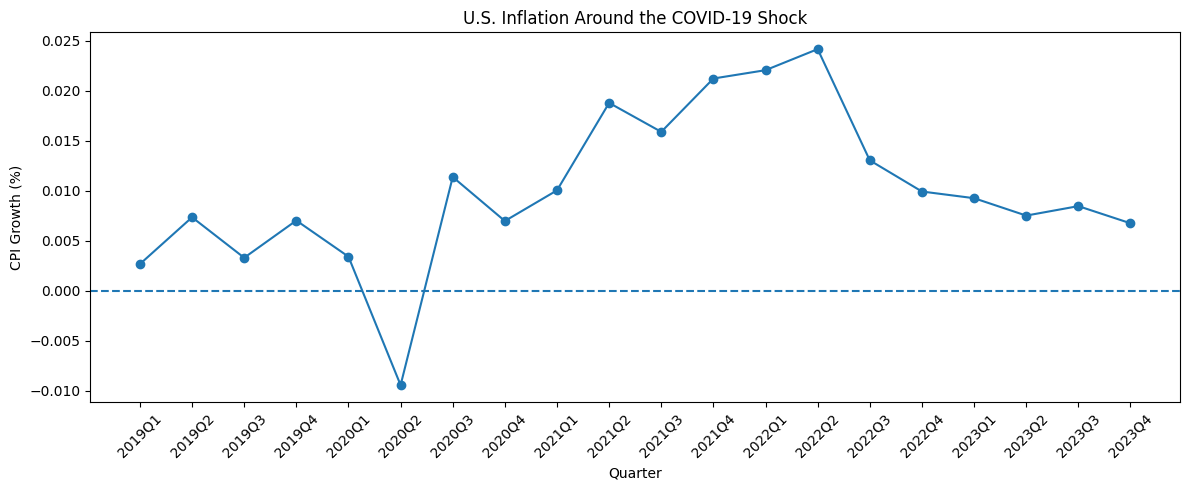

In [398]:
plt.figure(figsize=(12, 5))

plt.plot(
    inflation_period["year-quarter"],
    inflation_period["cpi_growth"],
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.title("U.S. Inflation Around the COVID-19 Shock")
plt.xlabel("Quarter")
plt.ylabel("CPI Growth (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### GDP growth & CPI growth plot

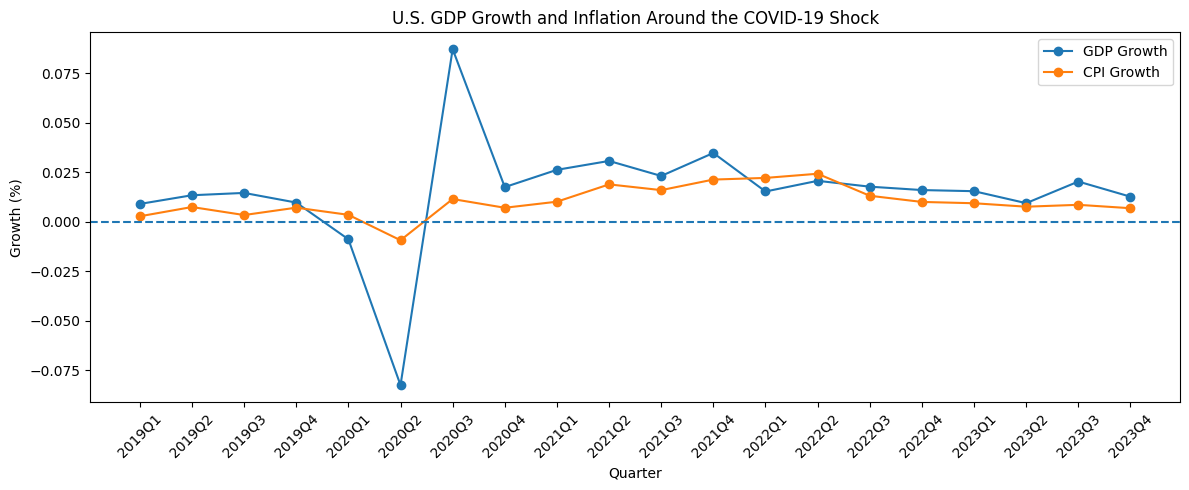

In [399]:
macro_covid = df_economy[
    ["year-quarter", "gdp_growth", "cpi_growth"]
].query(
    "`year-quarter` >= '2019Q1' and `year-quarter` <= '2023Q4'"
)

plt.figure(figsize=(12, 5))

plt.plot(
    macro_covid["year-quarter"],
    macro_covid["gdp_growth"],
    marker="o",
    label="GDP Growth"
)

plt.plot(
    macro_covid["year-quarter"],
    macro_covid["cpi_growth"],
    marker="o",
    label="CPI Growth"
)

plt.axhline(0, linestyle="--")

plt.title("U.S. GDP Growth and Inflation Around the COVID-19 Shock")
plt.xlabel("Quarter")
plt.ylabel("Growth (%)")

plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

### Inflation before and after covid

In [400]:
pre_covid_inflation = df_economy.query(
    "`year-quarter` >= '2018Q1' and `year-quarter` <= '2019Q4'"
)["cpi_growth"].mean()

covid_inflation_avg = df_economy.query(
    "`year-quarter` >= '2020Q1' and `year-quarter` <= '2020Q4'"
)["cpi_growth"].mean()

post_covid_inflation = df_economy.query(
    "`year-quarter` >= '2021Q1' and `year-quarter` <= '2022Q4'"
)["cpi_growth"].mean()

pre_covid_inflation, covid_inflation_avg, post_covid_inflation

(np.float64(0.005287422641216888),
 np.float64(0.003081075393554675),
 np.float64(0.016886576070915676))

### Policy timeline

In [401]:
policy_timeline = pd.DataFrame({
    "date": [
        "2020-03-03",
        "2020-03-15",
        "2020-03-23",
        "2020-03",
        "2020-12",
        "2022-03"
    ],
    "policy_area": [
        "Monetary",
        "Monetary",
        "Monetary",
        "Fiscal",
        "Fiscal",
        "Monetary"
    ],
    "action": [
        "Federal funds rate cut by 50 basis points",
        "Federal funds rate cut to 0–0.25% and asset purchases announced",
        "Expanded Treasury and MBS purchases and credit-market support",
        "CARES Act enacted",
        "Additional COVID fiscal support enacted",
        "Federal funds rate increased to 0.25–0.50%"
    ]
})

policy_timeline

,date,policy_area,action
0,2020-03-03,Monetary,Federal funds rate cut by 50 basis points
1,2020-03-15,Monetary,Federal funds rate cut to 0–0.25% and asset pu...
2,2020-03-23,Monetary,Expanded Treasury and MBS purchases and credit...
3,2020-03,Fiscal,CARES Act enacted
4,2020-12,Fiscal,Additional COVID fiscal support enacted
5,2022-03,Monetary,Federal funds rate increased to 0.25–0.50%


### Recovery analysis

In [402]:
pre_covid_gdp = df_economy.loc[
    df_economy["year-quarter"] == "2019Q4", "gdp"
].iloc[0]

pre_covid_unemployment = df_economy.loc[
    df_economy["year-quarter"] == "2019Q4",
    "unemployment_rate"
].iloc[0]

pre_covid_inflation = df_economy[
    df_economy["year-quarter"].between("2018Q1", "2019Q4")
]["cpi_growth"].mean()

print("Pre-COVID GDP:", pre_covid_gdp)
print("Pre-COVID unemployment:", pre_covid_unemployment)
print("Pre-COVID average inflation:", pre_covid_inflation)

Pre-COVID GDP: 21902.39
Pre-COVID unemployment: 3.6
Pre-COVID average inflation: 0.005287422641216888


In [403]:
recovery_period = df_economy[
    df_economy["year-quarter"].between("2020Q1", "2023Q4")
].copy()

recovery_period[
    [
        "year-quarter",
        "gdp",
        "gdp_growth",
        "unemployment_rate",
        "unemployment_change",
        "cpi_growth"
    ]
].head(15)

,year-quarter,gdp,gdp_growth,unemployment_rate,unemployment_change,cpi_growth
184,2020Q1,21706.5130,-0.0089,3.8333,0.2333,0.0034
185,2020Q2,19913.1430,-0.0826,13.0000,9.1667,-0.0094
186,2020Q3,21647.6400,0.0871,8.8000,-4.2000,0.0114
187,2020Q4,22024.5020,0.0174,6.7333,-2.0667,0.0070
188,2021Q1,22600.1850,0.0261,6.2333,-0.5000,0.0100
189,2021Q2,23292.3620,0.0306,5.9333,-0.3000,0.0188
190,2021Q3,23828.9730,0.0230,5.0667,-0.8667,0.0159
191,2021Q4,24654.6030,0.0346,4.1667,-0.9000,0.0212
192,2022Q1,25029.1160,0.0152,3.8000,-0.3667,0.0221
193,2022Q2,25544.2730,0.0206,3.6333,-0.1667,0.0242


# Question 4 — Crisis Duration and Recovery

## How long did the major U.S. economic crises last, and how long did it take for the economy to recover?

## 1. Economic Framework

### Recession Duration

Recession duration is the length of time between the peak and trough of economic activity.

In this analysis, the duration of a downturn is measured using the period between the identified GDP peak and GDP trough.

### Recovery

An economic recovery is the period following a downturn during which economic activity begins to increase toward its previous level.

Recovery is measured separately for GDP and unemployment because these indicators may recover at different speeds.

### Peak-to-Trough GDP Decline

Peak-to-trough GDP decline measures the percentage fall in real GDP from the pre-recession peak to the lowest GDP level during the downturn.

It provides a measure of the depth of the economic contraction.

### Time to Recovery

GDP recovery is defined as the first quarter after the GDP trough in which real GDP reaches or exceeds its pre-recession peak.

Unemployment recovery is defined as the first quarter after the downturn in which the unemployment rate returns to or below its level in the GDP peak quarter.

---

## 2. Measuring Crisis Severity

### GDP Decline

The major downturns identified in the dataset show substantial differences in GDP contraction.

| Crisis                   | GDP Peak | GDP Trough | Peak-to-Trough GDP Decline |
| ------------------------ | -------- | ---------- | -------------------------: |
| 1982 downturn            | 1981Q4   | 1982Q1     |                     -0.20% |
| 1990–91 recession        | 1990Q3   | 1990Q4     |                     -0.17% |
| 2001 recession           | 2001Q2   | 2001Q3     |                     -0.01% |
| 2008–09 financial crisis | 2008Q3   | 2009Q2     |                     -3.48% |
| COVID-19 recession       | 2019Q4   | 2020Q2     |                     -9.08% |

The COVID-19 recession produced the largest peak-to-trough decline in real GDP among the crises examined, with GDP falling by approximately 9.08%.

The 2008–09 financial crisis also produced a substantial contraction, while the GDP declines observed in the 1982, 1990–91, and 2001 episodes were much smaller in the quarterly data used in this analysis.

### Unemployment Increase

The unemployment rate also increased substantially during the major downturns.

| Crisis                   | Unemployment at GDP Peak | Unemployment Peak | Increase |
| ------------------------ | -----------------------: | ----------------: | -------: |
| 1982 downturn            |                    8.23% |            10.67% | +2.43 pp |
| 1990–91 recession        |                    5.70% |             7.63% | +1.93 pp |
| 2001 recession           |                    4.40% |             5.87% | +1.47 pp |
| 2008–09 financial crisis |                    6.00% |             9.93% | +3.93 pp |
| COVID-19 recession       |                    3.60% |            13.00% | +9.40 pp |

The largest increase in unemployment occurred during the COVID-19 recession. The unemployment rate increased from 3.60% at the pre-recession GDP peak to 13.00% at its peak, representing an increase of 9.40 percentage points.

The 2008–09 financial crisis produced the second-largest increase among the analyzed episodes.

### Employment Loss

A direct measure of employment loss cannot be calculated from the current dataset because it does not contain an employment-level variable.

Therefore, this analysis uses the unemployment rate as the available labor-ma


### Identifying major crisis

In [404]:
recession_periods = df_economy[
    df_economy["recession_flag"] == True
][
    [
        "year-quarter",
        "gdp",
        "gdp_growth",
        "unemployment_rate",
        "unemployment_change"
    ]
]

recession_periods

,year-quarter,gdp,gdp_growth,unemployment_rate,unemployment_change
32,1982Q1,3274.3020,-0.0020,8.8333,0.6000
67,1990Q4,6004.7330,-0.0017,6.1333,0.4333
110,2001Q3,10598.0200,-0.0001,4.8333,0.4333
136,2008Q1,14706.5380,-0.0006,5.0000,0.2000
139,2008Q4,14608.2090,-0.0195,6.8667,0.8667
140,2009Q1,14430.9020,-0.0121,8.2667,1.4000
141,2009Q2,14381.2360,-0.0034,9.3000,1.0333
184,2020Q1,21706.5130,-0.0089,3.8333,0.2333
185,2020Q2,19913.1430,-0.0826,13.0000,9.1667


In [405]:
negative_growth = df_economy[
    df_economy["gdp_growth"] < 0
][
    [
        "year-quarter",
        "gdp",
        "gdp_growth",
        "unemployment_rate",
        "unemployment_change"
    ]
]

negative_growth

,year-quarter,gdp,gdp_growth,unemployment_rate,unemployment_change
32,1982Q1,3274.3020,-0.0020,8.8333,0.6000
67,1990Q4,6004.7330,-0.0017,6.1333,0.4333
110,2001Q3,10598.0200,-0.0001,4.8333,0.4333
136,2008Q1,14706.5380,-0.0006,5.0000,0.2000
139,2008Q4,14608.2090,-0.0195,6.8667,0.8667
140,2009Q1,14430.9020,-0.0121,8.2667,1.4000
141,2009Q2,14381.2360,-0.0034,9.3000,1.0333
184,2020Q1,21706.5130,-0.0089,3.8333,0.2333
185,2020Q2,19913.1430,-0.0826,13.0000,9.1667


In [406]:
df_economy[
    [
        "year-quarter",
        "gdp",
        "gdp_growth",
        "unemployment_rate"
    ]
].loc[
    df_economy["year-quarter"].between("1979Q1", "2021Q4")
]

,year-quarter,gdp,gdp_growth,unemployment_rate
20,1979Q1,2526.6100,0.0200,5.8667
21,1979Q2,2591.2470,0.0256,5.7000
22,1979Q3,2667.5650,0.0295,5.8667
23,1979Q4,2723.8830,0.0211,5.9667
24,1980Q1,2789.8420,0.0242,6.3000
...,...,...,...,...
187,2020Q4,22024.5020,0.0174,6.7333
188,2021Q1,22600.1850,0.0261,6.2333
189,2021Q2,23292.3620,0.0306,5.9333
190,2021Q3,23828.9730,0.0230,5.0667


### Crisis intensity

In [407]:
crisis_windows = {
    "1982 downturn": ("1981Q1", "1983Q4"),
    "1990-91 recession": ("1989Q1", "1992Q4"),
    "2001 recession": ("2000Q1", "2002Q4"),
    "2008-09 financial crisis": ("2007Q1", "2010Q4"),
    "COVID-19 recession": ("2019Q1", "2021Q4")
}

for crisis, (start, end) in crisis_windows.items():

    data = df_economy[
        df_economy["year-quarter"].between(start, end)
    ].copy()

    print(f"\n{crisis}")
    print(data[[
        "year-quarter",
        "gdp",
        "gdp_growth",
        "unemployment_rate"
    ]].to_string(index=False))


1982 downturn
year-quarter       gdp  gdp_growth  unemployment_rate
      1981Q1 3124.2060      0.0464             7.4333
      1981Q2 3162.5320      0.0123             7.4000
      1981Q3 3260.6090      0.0310             7.4000
      1981Q4 3280.8180      0.0062             8.2333
      1982Q1 3274.3020     -0.0020             8.8333
      1982Q2 3331.9720      0.0176             9.4333
      1982Q3 3366.3220      0.0103             9.9000
      1982Q4 3402.5610      0.0108            10.6667
      1983Q1 3473.4130      0.0208            10.3667
      1983Q2 3578.8480      0.0304            10.1333
      1983Q3 3689.1790      0.0308             9.3667
      1983Q4 3794.7060      0.0286             8.5333

1990-91 recession
year-quarter       gdp  gdp_growth  unemployment_rate
      1989Q1 5511.2530      0.0207             5.2000
      1989Q2 5612.4630      0.0184             5.2333
      1989Q3 5695.3650      0.0148             5.2333
      1989Q4 5747.2370      0.0091             5

### Recovery

In [408]:
recovery_results = []

crises = {
    "1982 downturn": {
        "peak": "1981Q4",
        "trough": "1982Q1"
    },
    "1990-91 recession": {
        "peak": "1990Q3",
        "trough": "1990Q4"
    },
    "2001 recession": {
        "peak": "2001Q2",
        "trough": "2001Q3"
    },
    "2008-09 financial crisis": {
        "peak": "2008Q3",
        "trough": "2009Q2"
    },
    "COVID-19 recession": {
        "peak": "2019Q4",
        "trough": "2020Q2"
    }
}

for crisis, dates in crises.items():

    peak = dates["peak"]
    trough = dates["trough"]

    peak_gdp = df_economy.loc[
        df_economy["year-quarter"] == peak,
        "gdp"
    ].iloc[0]

    trough_gdp = df_economy.loc[
        df_economy["year-quarter"] == trough,
        "gdp"
    ].iloc[0]

    recovery_data = df_economy[
        df_economy["year-quarter"] > trough
    ]

    gdp_recovery = recovery_data[
        recovery_data["gdp"] >= peak_gdp
    ]

    if not gdp_recovery.empty:
        gdp_recovery_quarter = gdp_recovery.iloc[0]["year-quarter"]
    else:
        gdp_recovery_quarter = None

    recovery_results.append({
        "crisis": crisis,
        "GDP_peak": peak,
        "GDP_trough": trough,
        "GDP_recovery": gdp_recovery_quarter
    })

recovery_df = pd.DataFrame(recovery_results)

recovery_df

,crisis,GDP_peak,GDP_trough,GDP_recovery
0,1982 downturn,1981Q4,1982Q1,1982Q2
1,1990-91 recession,1990Q3,1990Q4,1991Q1
2,2001 recession,2001Q2,2001Q3,2001Q4
3,2008-09 financial crisis,2008Q3,2009Q2,2010Q2
4,COVID-19 recession,2019Q4,2020Q2,2020Q4


### Unemployment recovery

In [409]:
unemployment_recovery_results = []

for crisis, dates in crises.items():

    peak = dates["peak"]
    trough = dates["trough"]

    peak_unemployment = df_economy.loc[
        df_economy["year-quarter"] == peak,
        "unemployment_rate"
    ].iloc[0]

    recovery_data = df_economy[
        df_economy["year-quarter"] > trough
    ]

    unemployment_recovery = recovery_data[
        recovery_data["unemployment_rate"] <= peak_unemployment
    ]

    if not unemployment_recovery.empty:
        recovery_quarter = unemployment_recovery.iloc[0]["year-quarter"]
    else:
        recovery_quarter = None

    unemployment_recovery_results.append({
        "crisis": crisis,
        "unemployment_baseline": peak_unemployment,
        "unemployment_recovery": recovery_quarter
    })

unemployment_recovery_df = pd.DataFrame(
    unemployment_recovery_results
)

unemployment_recovery_df

,crisis,unemployment_baseline,unemployment_recovery
0,1982 downturn,8.2333,1984Q1
1,1990-91 recession,5.7000,1994Q4
2,2001 recession,4.4000,2017Q2
3,2008-09 financial crisis,6.0000,2014Q4
4,COVID-19 recession,3.6000,2022Q3


## Question 5 __ Measuring Business Cycle Changes

## Have U.S. business cycles become shorter, longer, weaker, or more volatile over time?

### Expansion Duration

Expansion duration was measured as the number of consecutive quarters without a recession according to the project's operational recession definition.

The average expansion duration was:

* **Pre-Great Moderation:** 33.0 quarters
* **Great Moderation:** 33.5 quarters
* **Post-Great Moderation:** 19.7 quarters

The median expansion duration was 33.0 quarters during the Pre-Great Moderation period and 33.5 quarters during the Great Moderation, but declined to 15.0 quarters in the Post-Great Moderation period.

This suggests that expansion periods were substantially shorter after 2007 within the sample and recession definition used in this analysis.

### Recession Duration

Recession duration was measured as the number of consecutive quarters classified as recession episodes.

The average recession duration was:

* **Pre-Great Moderation:** 1.0 quarter
* **Great Moderation:** 1.0 quarter
* **Post-Great Moderation:** 2.0 quarters

The maximum recession duration increased from 1 quarter in both earlier periods to 3 quarters in the Post-Great Moderation period.

### GDP Volatility

GDP growth volatility was measured using the standard deviation of quarterly real GDP growth.

GDP growth volatility was:

* **Pre-Great Moderation:** 0.0113
* **Great Moderation:** 0.0051
* **Post-Great Moderation:** 0.0173

GDP growth volatility declined substantially during the Great Moderation, but increased after 2007 to a level higher than in the Pre-Great Moderation period.

### Unemployment Volatility

Unemployment volatility was measured using the standard deviation of the unemployment rate.

The standard deviation of unemployment was:

* **Pre-Great Moderation:** 1.3901
* **Great Moderation:** 0.9902
* **Post-Great Moderation:** 2.2817

The results show a decline in unemployment volatility during the Great Moderation, followed by a substantial increase after 2007.

The volatility of quarterly changes in unemployment also followed the same pattern, declining from 0.5118 in the Pre-Great Moderation to 0.1959 during the Great Moderation, before increasing to 1.3369 in the Post-Great Moderation period.

### Inflation Volatility

Inflation volatility was measured using the standard deviation of quarterly CPI growth.

Inflation volatility declined from 0.0089 in the Pre-Great Moderation period to 0.0038 during the Great Moderation. It then increased to 0.0071 in the Post-Great Moderation period.

Therefore, the reduction in inflation volatility observed during the Great Moderation was not fully maintained after 2007.

---

## 4. Empirical Analysis

### Business Cycle Duration

The analysis identifies six recession episodes based on the project's operational recession definition:

| Period                | Recession Episodes | Average Duration | Maximum Duration |
| --------------------- | -----------------: | ---------------: | ---------------: |
| Pre-Great Moderation  |                  1 |     1.0 quarters |        1 quarter |
| Great Moderation      |                  2 |     1.0 quarters |        1 quarter |
| Post-Great Moderation |                  3 |     2.0 quarters |       3 quarters |

The number of recession episodes increased across the three periods. However, the periods have different lengths, so the raw number of episodes should not be interpreted as a direct measure of recession frequency.

A more informative measure is the share of quarters classified as recession:

* **Pre-Great Moderation:** 2.27%
* **Great Moderation:** 2.17%
* **Post-Great Moderation:** 9.23%

The recession share remained similar between the first two periods but increased substantially in the Post-Great Moderation period.

### Recession Frequency

The analysis identifies:

* 1 recession episode during the Pre-Great Moderation period
* 2 recession episodes during the Great Moderation period
* 3 recession episodes during the Post-Great Moderation period

Because the periods contain different numbers of quarters, recession share provides a more comparable measure. The Post-Great Moderation period had the highest recession share, with 9.23% of observed quarters classified as recession quarters.

### Economic Volatility Over Time

The volatility measures show a clear reduction during the Great Moderation.

GDP growth volatility declined from 0.0113 before the Great Moderation to 0.0051 during the Great Moderation. Unemployment volatility declined from 1.3901 to 0.9902, while inflation volatility declined from 0.0089 to 0.0038.

After 2007, volatility increased across all three variables. GDP growth volatility reached 0.0173, unemployment volatility reached 2.2817, and inflation volatility increased to 0.0071.

Therefore, the Great Moderation period represents the lowest-volatility period among the three periods considered in this analysis.

---

## 5. Comparing Economic Periods

### Earlier Periods

The Pre-Great Moderation period had relatively high macroeconomic volatility. GDP growth volatility was 0.0113, unemployment volatility was 1.3901, and inflation volatility was 0.0089.

Within the recession definition used in this project, one recession episode was identified during this period, lasting one quarter.

### Great Moderation

The Great Moderation was associated with substantially lower macroeconomic volatility.

GDP growth volatility fell by more than half compared with the Pre-Great Moderation period, from 0.0113 to 0.0051. Unemployment and inflation volatility also declined.

The average expansion duration remained broadly similar to the earlier period, increasing slightly from 33.0 to 33.5 quarters. At the same time, the identified recession episodes remained short, with an average duration of one quarter.

These results are consistent with the concept of the Great Moderation as a period of reduced macroeconomic fluctuations.

### Post-2007 Period

The Post-Great Moderation period shows a different pattern.

GDP growth volatility increased to 0.0173, which was higher than both earlier periods. Unemployment volatility increased substantially to 2.2817, while inflation volatility increased to 0.0071.

Recessions also accounted for a larger share of observed quarters, increasing to 9.23%. The average recession duration increased to two quarters, and the longest identified recession episode lasted three quarters.

At the same time, average expansion duration declined to 19.7 quarters, compared with 33.0 quarters before the Great Moderation and 33.5 quarters during the Great Moderation.

---

## 6. Economic Interpretation

The empirical results suggest that U.S. business-cycle characteristics changed considerably across the three periods examined.

First, the Great Moderation was characterized by lower volatility across GDP growth, unemployment, and inflation. This indicates that fluctuations in major macroeconomic variables became more moderate during this period.

Second, the Post-Great Moderation period shows a substantial increase in volatility. This result is consistent with the presence of major economic shocks during this period, particularly the Global Financial Crisis and the COVID-19 recession. However, the analysis is descriptive and does not establish that these events alone caused the observed changes in volatility.

Third, the duration measures suggest that expansion periods became shorter and recession episodes became longer in the Post-2007 period according to the recession definition used in this project.

The severity measures also indicate larger downturns after 2007. Average minimum GDP growth during identified recession episodes declined from -0.0020 in the Pre-Great Moderation period and -0.0009 during the Great Moderation to -0.0342 in the Post-Great Moderation period. The worst quarterly GDP growth observed within a recession episode was -0.0826 in the Post-Great Moderation period.

The average maximum quarterly increase in unemployment during recession episodes also increased substantially, from 0.6000 in the Pre-Great Moderation period and 0.4333 during the Great Moderation to 3.5889 after 2007.

These findings indicate that the Post-2007 period was characterized not only by higher overall volatility but also by larger observed downturns in the variables examined.

However, these results should be interpreted with caution. The three periods differ in length, and the Post-Great Moderation period includes two exceptional episodes—the Global Financial Crisis and the COVID-19 recession—which can strongly affect standard deviation and recession statistics. In addition, recession episodes in this project are identified using an operational rule based on GDP growth and changes in unemployment rather than the official NBER business-cycle chronology.

---

## 7. Conclusion

The analysis does not support a single description such as simply "shorter" or "longer." Instead, the results vary across different dimensions of the business cycle.

The **Great Moderation** was associated with substantially lower volatility in GDP growth, unemployment, and inflation, while expansion and recession durations remained broadly stable relative to the earlier period.

The **Post-Great Moderation period** shows higher volatility, a larger share of recession quarters, longer average recession episodes, shorter average expansion periods, and more severe observed downturns according to the project's measures.

Overall, within this dataset and operational framework, U.S. business cycles appear to have become **less volatile during the Great Moderation but more volatile and more disruptive after 2007**. The post-2007 results are strongly influenced by major shocks such as the Global Financial Crisis and the COVID-19 recession, so they should not be interpreted as evidence of a permanent structural change in the U.S. business cycle.


### Volatility

In [410]:
periods = {
    "Pre-Great Moderation": ("1974Q1", "1984Q4"),
    "Great Moderation": ("1985Q1", "2007Q4"),
    "Post-Great Moderation": ("2008Q1", "2024Q1")
}

volatility_results = []

for period, (start, end) in periods.items():

    data = df_economy[
        df_economy["year-quarter"].between(start, end)
    ]

    volatility_results.append({
        "period": period,
        "GDP_growth_volatility": data["gdp_growth"].std(),
        "Unemployment_volatility": data["unemployment_rate"].std(),
        "Unemployment_change_volatility": data["unemployment_change"].std(),
        "Inflation_volatility": data["cpi_growth"].std()
    })

volatility_df = pd.DataFrame(volatility_results)

volatility_df

,period,GDP_growth_volatility,Unemployment_volatility,Unemployment_change_volatility,Inflation_volatility
0,Pre-Great Moderation,0.0113,1.3901,0.5118,0.0089
1,Great Moderation,0.0051,0.9902,0.1959,0.0038
2,Post-Great Moderation,0.0173,2.2817,1.3369,0.0071


### Cycle Duration & Recession frequency

In [411]:
recession_frequency = []

for period, (start, end) in periods.items():

    data = df_economy[
        df_economy["year-quarter"].between(start, end)
    ]

    recession_quarters = data["recession_flag"].sum()

    recession_frequency.append({
        "period": period,
        "recession_quarters": recession_quarters
    })

recession_frequency_df = pd.DataFrame(recession_frequency)

recession_frequency_df

,period,recession_quarters
0,Pre-Great Moderation,1
1,Great Moderation,2
2,Post-Great Moderation,6


In [412]:
recession_data = df_economy[
    df_economy["recession_flag"] == True
][["year-quarter"]].copy()

recession_data["quarter"] = pd.PeriodIndex(
    recession_data["year-quarter"],
    freq="Q"
)

recession_data["quarter_ordinal"] = (
    recession_data["quarter"].map(lambda x: x.ordinal)
)

recession_data["gap"] = (
    recession_data["quarter_ordinal"].diff()
)

recession_data["episode"] = (
    recession_data["gap"].fillna(1).ne(1).cumsum()
)

recession_episodes = (
    recession_data
    .groupby("episode")
    .agg(
        start=("year-quarter", "first"),
        end=("year-quarter", "last"),
        duration_quarters=("quarter", "size")
    )
    .reset_index(drop=True)
)

recession_episodes

,start,end,duration_quarters
0,1982Q1,1982Q1,1
1,1990Q4,1990Q4,1
2,2001Q3,2001Q3,1
3,2008Q1,2008Q1,1
4,2008Q4,2009Q2,3
5,2020Q1,2020Q2,2


In [413]:
recession_frequency = []

for period, (start, end) in periods.items():

    data = df_economy[
        df_economy["year-quarter"].between(start, end)
    ]

    period_start = pd.Period(start, freq="Q")
    period_end = pd.Period(end, freq="Q")

    period_recessions = recession_episodes[
        (
            pd.PeriodIndex(
                recession_episodes["start"],
                freq="Q"
            ) >= period_start
        )
        &
        (
            pd.PeriodIndex(
                recession_episodes["start"],
                freq="Q"
            ) <= period_end
        )
    ]

    recession_frequency.append({
        "period": period,
        "recession_episodes": len(period_recessions),
        "recession_quarters": data["recession_flag"].sum(),
        "total_quarters": len(data),
        "recession_share": (
            data["recession_flag"].mean()
        )
    })

recession_frequency_df = pd.DataFrame(recession_frequency)

recession_frequency_df

,period,recession_episodes,recession_quarters,total_quarters,recession_share
0,Pre-Great Moderation,1,1,44,0.0227
1,Great Moderation,2,2,92,0.0217
2,Post-Great Moderation,3,6,65,0.0923


### Duration

In [414]:
duration_results = []

for period, (start, end) in periods.items():

    period_start = pd.Period(start, freq="Q")
    period_end = pd.Period(end, freq="Q")

    period_recessions = recession_episodes[
        (
            pd.PeriodIndex(
                recession_episodes["start"],
                freq="Q"
            ) >= period_start
        )
        &
        (
            pd.PeriodIndex(
                recession_episodes["start"],
                freq="Q"
            ) <= period_end
        )
    ]

    duration_results.append({
        "period": period,
        "number_of_recessions": len(period_recessions),
        "average_recession_duration": (
            period_recessions["duration_quarters"].mean()
        ),
        "median_recession_duration": (
            period_recessions["duration_quarters"].median()
        ),
        "maximum_recession_duration": (
            period_recessions["duration_quarters"].max()
        )
    })

duration_df = pd.DataFrame(duration_results)

duration_df

,period,number_of_recessions,average_recession_duration,median_recession_duration,maximum_recession_duration
0,Pre-Great Moderation,1,1.0000,1.0000,1
1,Great Moderation,2,1.0000,1.0000,1
2,Post-Great Moderation,3,2.0000,2.0000,3


### Expansion Duration

In [415]:
non_recession_data = df_economy[
    df_economy["recession_flag"] == False
][["year-quarter"]].copy()

non_recession_data["quarter"] = pd.PeriodIndex(
    non_recession_data["year-quarter"],
    freq="Q"
)

non_recession_data["quarter_ordinal"] = (
    non_recession_data["quarter"].map(lambda x: x.ordinal)
)

non_recession_data["gap"] = (
    non_recession_data["quarter_ordinal"].diff()
)

non_recession_data["episode"] = (
    non_recession_data["gap"].fillna(1).ne(1).cumsum()
)

expansion_episodes = (
    non_recession_data
    .groupby("episode")
    .agg(
        start=("year-quarter", "first"),
        end=("year-quarter", "last"),
        duration_quarters=("quarter", "size")
    )
    .reset_index(drop=True)
)

expansion_episodes

,start,end,duration_quarters
0,1974Q1,1981Q4,32
1,1982Q2,1990Q3,34
2,1991Q1,2001Q2,42
3,2001Q4,2007Q4,25
4,2008Q2,2008Q3,2
5,2009Q3,2019Q4,42
6,2020Q3,2024Q1,15


In [416]:
expansion_duration_results = []

for period, (start, end) in periods.items():

    period_start = pd.Period(start, freq="Q")
    period_end = pd.Period(end, freq="Q")

    period_expansions = expansion_episodes[
        (
            pd.PeriodIndex(
                expansion_episodes["start"],
                freq="Q"
            ) >= period_start
        )
        &
        (
            pd.PeriodIndex(
                expansion_episodes["start"],
                freq="Q"
            ) <= period_end
        )
    ]

    expansion_duration_results.append({
        "period": period,
        "number_of_expansions": len(period_expansions),
        "average_expansion_duration": (
            period_expansions["duration_quarters"].mean()
        ),
        "median_expansion_duration": (
            period_expansions["duration_quarters"].median()
        ),
        "maximum_expansion_duration": (
            period_expansions["duration_quarters"].max()
        )
    })

expansion_duration_df = pd.DataFrame(
    expansion_duration_results
)

expansion_duration_df

,period,number_of_expansions,average_expansion_duration,median_expansion_duration,maximum_expansion_duration
0,Pre-Great Moderation,2,33.0000,33.0000,34
1,Great Moderation,2,33.5000,33.5000,42
2,Post-Great Moderation,3,19.6667,15.0000,42


### Recession severity

In [417]:
recession_severity = []

for _, episode in recession_episodes.iterrows():

    data = df_economy[
        df_economy["year-quarter"].between(
            episode["start"],
            episode["end"]
        )
    ]

    recession_severity.append({
        "start": episode["start"],
        "end": episode["end"],
        "duration_quarters": episode["duration_quarters"],
        "min_gdp_growth": data["gdp_growth"].min(),
        "max_unemployment_change": data["unemployment_change"].max(),
        "max_inflation": data["cpi_growth"].max()
    })

recession_severity_df = pd.DataFrame(
    recession_severity
)

recession_severity_df

,start,end,duration_quarters,min_gdp_growth,max_unemployment_change,max_inflation
0,1982Q1,1982Q1,1,-0.0020,0.6000,0.0089
1,1990Q4,1990Q4,1,-0.0017,0.4333,0.0170
2,2001Q3,2001Q3,1,-0.0001,0.4333,0.0028
3,2008Q1,2008Q1,1,-0.0006,0.2000,0.0108
4,2008Q4,2009Q2,3,-0.0195,1.4000,0.0053
5,2020Q1,2020Q2,2,-0.0826,9.1667,0.0034


In [418]:
severity_results = []

for period, (start, end) in periods.items():

    period_start = pd.Period(start, freq="Q")
    period_end = pd.Period(end, freq="Q")

    period_recessions = recession_severity_df[
        (
            pd.PeriodIndex(
                recession_severity_df["start"],
                freq="Q"
            ) >= period_start
        )
        &
        (
            pd.PeriodIndex(
                recession_severity_df["start"],
                freq="Q"
            ) <= period_end
        )
    ]

    severity_results.append({
        "period": period,
        "average_min_gdp_growth": (
            period_recessions["min_gdp_growth"].mean()
        ),
        "worst_gdp_growth": (
            period_recessions["min_gdp_growth"].min()
        ),
        "average_max_unemployment_change": (
            period_recessions["max_unemployment_change"].mean()
        )
    })

severity_df = pd.DataFrame(severity_results)

severity_df

,period,average_min_gdp_growth,worst_gdp_growth,average_max_unemployment_change
0,Pre-Great Moderation,-0.0020,-0.0020,0.6000
1,Great Moderation,-0.0009,-0.0017,0.4333
2,Post-Great Moderation,-0.0342,-0.0826,3.5889


### Summary of business cycle characteristics

In [419]:
cycle_summary = (
    volatility_df
    .merge(
        recession_frequency_df,
        on="period"
    )
    .merge(
        duration_df,
        on="period"
    )
    .merge(
        expansion_duration_df,
        on="period"
    )
    .merge(
        severity_df,
        on="period"
    )
)

cycle_summary

,period,GDP_growth_volatility,Unemployment_volatility,Unemployment_change_volatility,Inflation_volatility,recession_episodes,recession_quarters,total_quarters,recession_share,number_of_recessions,average_recession_duration,median_recession_duration,maximum_recession_duration,number_of_expansions,average_expansion_duration,median_expansion_duration,maximum_expansion_duration,average_min_gdp_growth,worst_gdp_growth,average_max_unemployment_change
0,Pre-Great Moderation,0.0113,1.3901,0.5118,0.0089,1,1,44,0.0227,1,1.0000,1.0000,1,2,33.0000,33.0000,34,-0.0020,-0.0020,0.6000
1,Great Moderation,0.0051,0.9902,0.1959,0.0038,2,2,92,0.0217,2,1.0000,1.0000,1,2,33.5000,33.5000,42,-0.0009,-0.0017,0.4333
2,Post-Great Moderation,0.0173,2.2817,1.3369,0.0071,3,6,65,0.0923,3,2.0000,2.0000,3,3,19.6667,15.0000,42,-0.0342,-0.0826,3.5889


### plots

#### Volatility

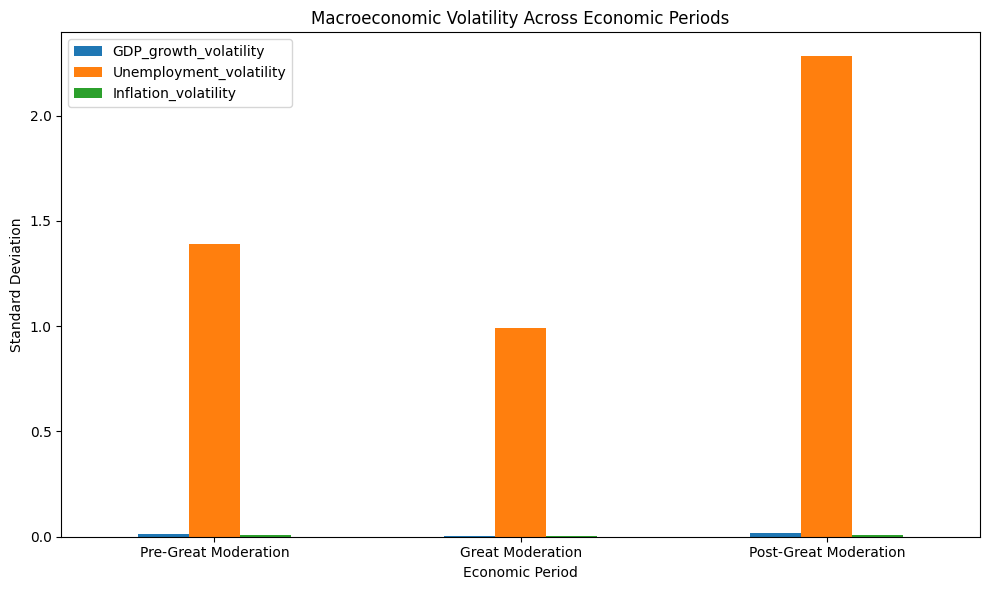

In [420]:
volatility_plot = volatility_df.set_index("period")[
    [
        "GDP_growth_volatility",
        "Unemployment_volatility",
        "Inflation_volatility"
    ]
]

volatility_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Macroeconomic Volatility Across Economic Periods")
plt.xlabel("Economic Period")
plt.ylabel("Standard Deviation")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

#### Recession duration

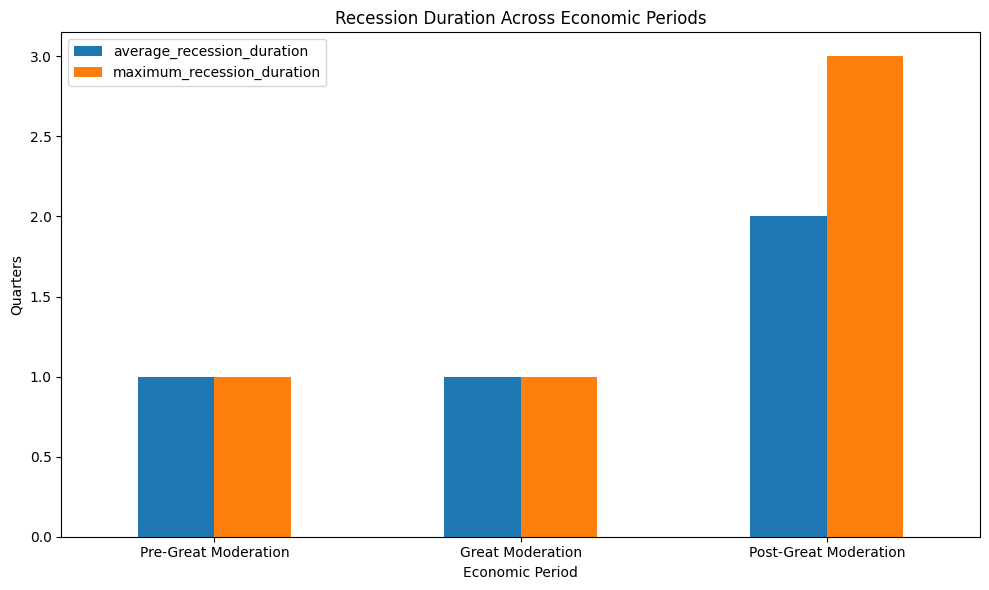

In [421]:
duration_plot = duration_df.set_index("period")[
    [
        "average_recession_duration",
        "maximum_recession_duration"
    ]
]

duration_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Recession Duration Across Economic Periods")
plt.xlabel("Economic Period")
plt.ylabel("Quarters")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

#### Recession frequency

In [422]:
frequency_plot = recession_frequency_df.set_index("period")[
    ["recession_episodes", "recession_share"]
]

frequency_plot

,recession_episodes,recession_share
period,,
Pre-Great Moderation,1,0.0227
Great Moderation,2,0.0217
Post-Great Moderation,3,0.0923


# Question 6 — Unemployment Response to Output Changes

## How does unemployment respond to changes in economic output during expansions and recessions?

## 1. Economic Framework

### Cyclical Unemployment

Cyclical unemployment is the component of unemployment associated with fluctuations in aggregate economic activity. It tends to rise during economic downturns and decline during expansions.

### Okun's Law

Okun's Law describes an empirical relationship between changes in economic output and changes in unemployment. In general, stronger economic growth is associated with lower unemployment, while weaker output growth is associated with increases in unemployment.

The relationship is not an exact structural law. Its magnitude can vary across time because labor-market institutions, productivity, labor-force participation, hiring behavior, and the nature of economic shocks can change.

### Labor-Market Adjustment

Labor-market adjustment refers to the process through which employment and unemployment respond to changes in economic activity. Firms may adjust employment through changes in hours worked, hiring, layoffs, and other labor-market responses.

---

## 2. Theoretical Mechanism

### Output Decline and Unemployment

When economic output declines, firms typically face weaker demand for goods and services. They may respond by reducing working hours, slowing hiring, or laying off workers. These adjustments can increase unemployment.

### Output Growth and Employment

During an expansion, stronger demand and higher production can increase firms' demand for labor. Firms may increase hiring and working hours, contributing to lower unemployment.

### Asymmetry Between Expansions and Recessions

The relationship between output growth and unemployment does not necessarily have the same magnitude during expansions and contractions. Firms may adjust employment differently during severe downturns, and unusual shocks can generate exceptionally large labor-market responses.

Therefore, examining the relationship separately during expansions and contractions can provide additional information beyond the full-sample relationship.

---

## 3. Empirical Analysis

### GDP Growth and Unemployment Change

The full sample contains a strong negative relationship between real GDP growth and changes in unemployment.

The correlation between GDP growth and the change in the unemployment rate is:

**-0.7297**

This indicates that quarters with stronger GDP growth generally coincide with smaller increases, or larger decreases, in unemployment. Conversely, weaker GDP growth tends to be associated with increases in unemployment.

The negative sign is consistent with the expected direction of Okun's Law.

### Expansions vs. Contractions

The relationship is negative in both phases of the business cycle:

| Phase       | Correlation |
| ----------- | ----------: |
| Expansion   |     -0.5309 |
| Contraction |     -0.9771 |

The relationship is substantially stronger during contraction periods in this sample. However, the contraction sample contains only **9 observations**, so the very high correlation should be interpreted cautiously.

In particular, the COVID-19 period represents an unusually large labor-market shock and has a major influence on the contraction results.

---

## 4. Statistical Analysis

### Correlation

The overall correlation between GDP growth and changes in unemployment is:

$$
r = -0.7297
$$

This indicates a strong negative association between the two variables over the sample period.

However, correlation alone does not establish causality. It describes the strength and direction of the statistical association between GDP growth and unemployment changes.

### Regression Model

To quantify the relationship, the following ordinary least squares model was estimated:

$$
\Delta U_t = \alpha + \beta GDPGrowth_t + \epsilon_t
$$

where:

* \(\Delta U_t\) = quarterly change in the unemployment rate
* \(GDPGrowth_t\) = quarterly real GDP growth
* \(\alpha\) = intercept
* \(\beta\) = estimated response of unemployment changes to GDP growth

### Regression Results

The estimated coefficient on GDP growth is:

$$
\beta = -46.2666
$$

with a p-value below 0.001 and an \(R^2\) of approximately **0.5324**.

The estimated model is therefore:

$$
\Delta U_t = 0.6822 - 46.2666GDPGrowth_t
$$

The negative coefficient indicates that higher GDP growth is associated with smaller increases in unemployment, while lower GDP growth is associated with larger increases in unemployment.

The model explains approximately **53.2%** of the variation in quarterly unemployment changes in the sample.

The estimated relationship is statistically significant, although the regression should be interpreted as an empirical association rather than a causal estimate.

---

## 5. Expansions vs. Contractions

Separate regressions were estimated for expansion and contraction periods.

| Phase       | GDP Coefficient | p-value |     R² | Observations |
| ----------- | --------------: | ------: | -----: | -----------: |
| All Periods |        -46.2666 |  <0.001 | 0.5324 |          200 |
| Expansion   |        -24.5020 |  <0.001 | 0.2819 |          191 |
| Contraction |       -106.3626 |  <0.001 | 0.9548 |            9 |

### Expansion

During expansion periods, the estimated GDP coefficient is:

$$
\beta_{Expansion} = -24.5020
$$

The coefficient is statistically significant and the model explains approximately **28.2%** of the variation in unemployment changes.

This indicates that the negative relationship between output growth and unemployment is present even when the economy is expanding, although the relationship is weaker than in the contraction subsample.

### Contraction

During contraction periods, the estimated coefficient is:

$$
\beta_{Contraction} = -106.3626
$$

The model has an \(R^2\) of approximately **0.955**.

However, this result should be interpreted with considerable caution. There are only **9 contraction observations**, and the COVID-19 episode represents an exceptionally large observation within this small subsample.

Therefore, the very large contraction coefficient should not be interpreted as a stable estimate of how unemployment responds to every recession.

---

## 6. Unemployment Response During Major Downturns

The largest negative GDP growth observation occurs in **2020 Q2**, when GDP growth in the dataset is approximately **-8.26%** and the unemployment rate increased by approximately **9.17 percentage points**.

This observation is substantially larger than the other major downturn observations in the dataset.

Other notable downturn-related observations include:

* 2008 Q4: GDP growth of approximately -1.95% and unemployment increase of 0.87 percentage points.
* 2009 Q1: GDP growth of approximately -1.21% and unemployment increase of 1.40 percentage points.
* 2009 Q2: GDP growth of approximately -0.34% and unemployment increase of 1.03 percentage points.
* 1982 Q1: GDP growth of approximately -0.20% and unemployment increase of 0.60 percentage points.
* 1990 Q4: GDP growth of approximately -0.17% and unemployment increase of 0.43 percentage points.

These observations show that major downturns are generally associated with increases in unemployment, but the magnitude of the response differs considerably across episodes.

### COVID-19

The COVID-19 period is particularly important because the labor-market response was much larger and faster than most other observations in the sample.

| Period  | GDP Growth | Change in Unemployment |
| ------- | ---------: | ---------------------: |
| 2020 Q1 |     -0.89% |               +0.23 pp |
| 2020 Q2 |     -8.26% |               +9.17 pp |
| 2020 Q3 |     +8.71% |               -4.20 pp |
| 2020 Q4 |     +1.74% |               -2.07 pp |
| 2021 Q1 |     +2.61% |               -0.50 pp |

The second quarter of 2020 stands out as an extreme observation. The subsequent quarters also show a rapid decline in unemployment as output recovered.

This episode helps explain the extremely strong relationship observed in the contraction subsample.

---

## 7. Contemporaneous vs. Lagged Response

To examine whether unemployment responds with a delay, a one-quarter lag of GDP growth was included in a second regression.

The results are:

| Model           | GDP Coefficient | p-value |     R² |
| --------------- | --------------: | ------: | -----: |
| Contemporaneous |        -46.2666 |  <0.001 | 0.5324 |
| One-quarter lag |         -4.8489 |  0.2831 | 0.0058 |

The contemporaneous relationship is strong and statistically significant, whereas the one-quarter lagged GDP coefficient is not statistically significant.

The lagged model explains only approximately **0.6%** of the variation in unemployment changes.

Within this simple specification, the results therefore provide stronger evidence of a contemporaneous association between GDP growth and unemployment changes than of a one-quarter delayed relationship.

This finding should not be interpreted as proof that labor-market adjustment never occurs with a lag. More detailed dynamic models would be required to investigate adjustment over multiple quarters.

---

## 8. Economic Interpretation

The empirical results are broadly consistent with Okun's Law.

Across the full sample, GDP growth and changes in unemployment exhibit a strong negative relationship. Periods of stronger output growth tend to be associated with declining or slower-growing unemployment, while weak or negative output growth tends to coincide with increases in unemployment.

The relationship is present in both expansions and contractions, but its estimated magnitude differs substantially between the two groups.

The contraction regression produces a much larger coefficient and a much higher \(R^2\). However, this result is based on only nine observations and is strongly influenced by the exceptional COVID-19 shock. Therefore, it should not be interpreted as evidence that unemployment always responds more than four times as strongly to output changes during recessions.

The COVID-19 episode demonstrates why the magnitude of Okun's relationship can vary substantially across economic episodes. The sharp decline in output in 2020 Q2 was accompanied by an unprecedented increase in unemployment, followed by a rapid labor-market improvement as output recovered.

The lagged analysis also suggests that, in this dataset and specification, the contemporaneous relationship between GDP growth and unemployment changes is much stronger than the one-quarter lagged relationship.

---

## 9. Limitations

Several limitations should be considered when interpreting these results.

### 1. Correlation Does Not Establish Causality

The regression identifies a statistical association between GDP growth and unemployment changes. It does not establish that changes in GDP growth directly cause the observed changes in unemployment.

### 2. Small Contraction Sample

Only nine observations are classified as contractions under the definition used in this analysis. Consequently, the contraction-specific regression is sensitive to individual observations.

### 3. COVID-19 as an Extreme Observation

The COVID-19 recession generated an unusually large decline in output and increase in unemployment. This observation has a substantial influence on the contraction results and should be distinguished from more conventional business-cycle downturns.

### 4. Simple Regression Specification

The model contains only GDP growth as an explanatory variable. Other factors affecting unemployment—including labor-force participation, productivity, employment dynamics, industry composition, and the nature of individual economic shocks—are not explicitly controlled for.

### 5. Residual Diagnostics

The full-sample regression shows strong departures from normality in the residuals, with a high Jarque-Bera statistic and substantial skewness and kurtosis. The Durbin-Watson statistic is also below 2, suggesting that serial correlation may warrant further investigation.

Therefore, the regression should primarily be interpreted as a descriptive empirical analysis rather than a fully specified econometric model.

---

## 10. Conclusion

The analysis finds a strong negative relationship between real GDP growth and changes in the U.S. unemployment rate over the sample period.

The full-sample correlation is **-0.7297**, while the OLS coefficient on GDP growth is **-46.27**, with the relationship statistically significant and an \(R^2\) of approximately **0.53**.

The negative relationship is also present separately during expansions and contractions. The estimated relationship is stronger during contraction periods, but the contraction sample contains only nine observations and is heavily influenced by the exceptional COVID-19 episode.

The 2020 recession represents the clearest example of a large and rapid labor-market response to an output shock: GDP growth fell sharply in 2020 Q2 while the unemployment rate increased by approximately 9.17 percenta


### Making features

In [423]:
df_economy["period"] = pd.to_datetime(df_economy["year-quarter"])

C:\Users\Asus\AppData\Local\Temp\ipykernel_23980\1971237117.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_economy["period"] = pd.to_datetime(df_economy["year-quarter"])


In [424]:
df_economy = df_economy.sort_values("period").copy()

In [425]:
df_economy[["period", "gdp_growth", "unemployment_change"]].head(10)

,period,gdp_growth,unemployment_change
0,1974-01-01,NaN,NaN
1,1974-04-01,0.0261,0.0667
2,1974-07-01,0.0196,0.4333
3,1974-10-01,0.0254,0.9667
4,1975-01-01,0.0103,1.6667
5,1975-04-01,0.0221,0.6000
6,1975-07-01,0.0351,-0.4000
7,1975-10-01,0.0304,-0.1667
8,1976-01-01,0.0333,-0.5667
9,1976-04-01,0.0175,-0.1667


### Expansion & Recession 

In [426]:
df_economy["phase"] = np.where(
    df_economy["gdp_growth"] > 0,
    "Expansion",
    "Contraction"
)

In [427]:
df_economy["phase"].value_counts()

phase
Expansion      191
Contraction     10
Name: count, dtype: int64

### GDP growth & Unemployment change relationship

In [428]:
df_economy[["gdp_growth", "unemployment_change"]].describe()

,gdp_growth,unemployment_change
count,200.0000,200.0000
mean,0.0149,-0.0072
std,0.0127,0.8054
min,-0.0826,-4.2000
25%,0.0103,-0.2000
50%,0.0138,-0.0667
75%,0.0191,0.0667
max,0.0871,9.1667


In [429]:
correlation = df_economy["gdp_growth"].corr(df_economy["unemployment_change"])

print(f"Correlation: {correlation:.4f}")

Correlation: -0.7297


### Scatter plot

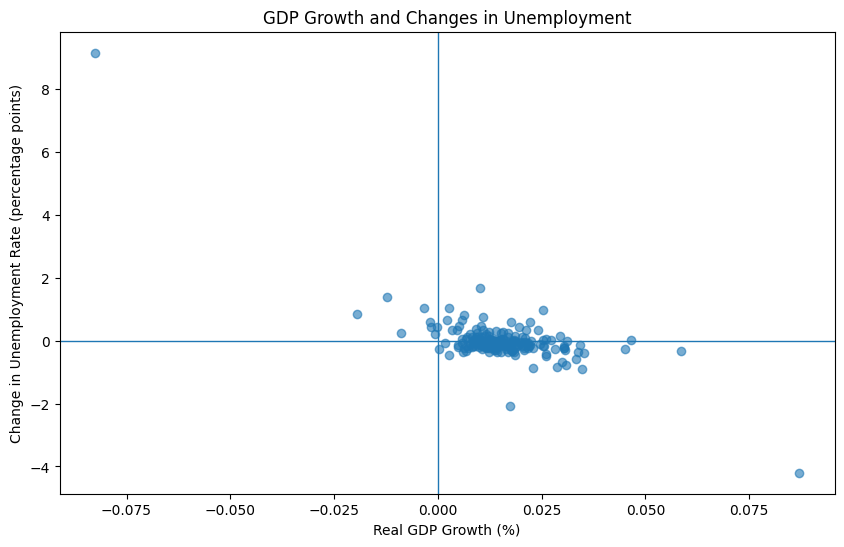

In [430]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_economy["gdp_growth"],
    df_economy["unemployment_change"],
    alpha=0.6
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel("Real GDP Growth (%)")
plt.ylabel("Change in Unemployment Rate (percentage points)")
plt.title("GDP Growth and Changes in Unemployment")

plt.show()

### Regression

In [431]:
X = sm.add_constant(df_economy["gdp_growth"].dropna())
y = df_economy["unemployment_change"].dropna()

model = sm.OLS(y, X).fit()

In [432]:
model.params

const          0.6822
gdp_growth   -46.2666
dtype: float64

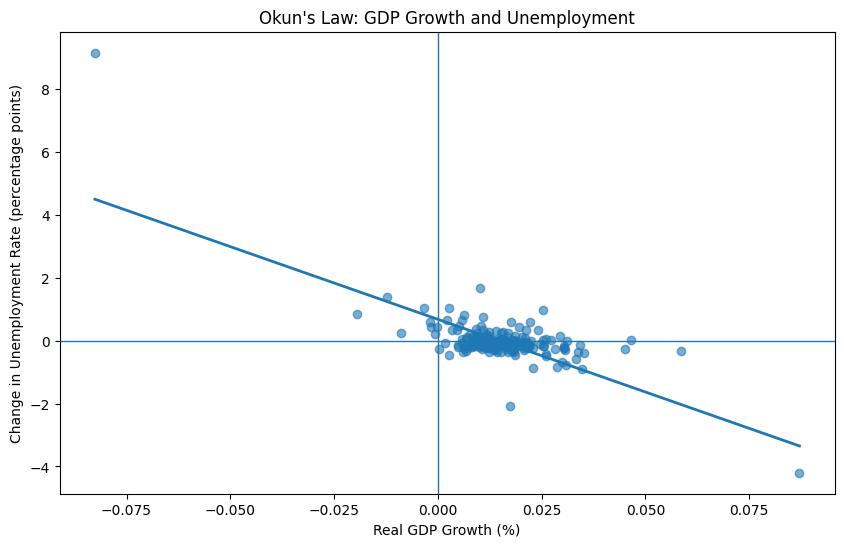

In [433]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_economy["gdp_growth"],
    df_economy["unemployment_change"],
    alpha=0.6
)

x_values = np.linspace(
    df_economy["gdp_growth"].min(),
    df_economy["gdp_growth"].max(),
    100
)

X_line = sm.add_constant(x_values)
y_pred = model.predict(X_line)

plt.plot(
    x_values,
    y_pred,
    linewidth=2
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel("Real GDP Growth (%)")
plt.ylabel("Change in Unemployment Rate (percentage points)")
plt.title("Okun's Law: GDP Growth and Unemployment")

plt.show()

In [434]:
print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     unemployment_change   R-squared:                       0.532
Model:                             OLS   Adj. R-squared:                  0.530
Method:                  Least Squares   F-statistic:                     225.4
Date:                 Fri, 18 Sep 2026   Prob (F-statistic):           1.60e-34
Time:                         20:08:00   Log-Likelihood:                -163.98
No. Observations:                  200   AIC:                             332.0
Df Residuals:                      198   BIC:                             338.6
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6822      0.060     11.32

### Okun's law coefficient

In [435]:
beta = model.params["gdp_growth"]

print(f"Okun coefficient: {beta:.4f}")

Okun coefficient: -46.2666


In [436]:
p_value = model.pvalues["gdp_growth"]

print(f"p-value: {p_value:.4f}")

p-value: 0.0000


### Expantion vs Contraction

In [437]:
phase_correlation = (
    df_economy.groupby("phase")[["gdp_growth", "unemployment_change"]]
      .corr()
      .iloc[0::2, -1]
)

phase_correlation

phase                  
Contraction  gdp_growth   -0.9771
Expansion    gdp_growth   -0.5309
Name: unemployment_change, dtype: float64

In [438]:
expansion_corr = (
    df_economy.loc[df_economy["phase"] == "Expansion", "gdp_growth"]
    .corr(
        df_economy.loc[df_economy["phase"] == "Expansion", "unemployment_change"]
    )
)

contraction_corr = (
    df_economy.loc[df_economy["phase"] == "Contraction", "gdp_growth"]
    .corr(
        df_economy.loc[df_economy["phase"] == "Contraction", "unemployment_change"]
    )
)

print(f"Expansion correlation: {expansion_corr:.4f}")
print(f"Contraction correlation: {contraction_corr:.4f}")

Expansion correlation: -0.5309
Contraction correlation: -0.9771


### regression

#### Expantion

In [439]:
expansion = df_economy[df_economy["phase"] == "Expansion"].copy()

X_exp = sm.add_constant(expansion["gdp_growth"])
y_exp = expansion["unemployment_change"]

model_exp = sm.OLS(y_exp, X_exp).fit()

print(model_exp.summary())

                             OLS Regression Results                            
Dep. Variable:     unemployment_change   R-squared:                       0.282
Model:                             OLS   Adj. R-squared:                  0.278
Method:                  Least Squares   F-statistic:                     74.20
Date:                 Fri, 18 Sep 2026   Prob (F-statistic):           2.76e-15
Time:                         20:08:00   Log-Likelihood:                -88.012
No. Observations:                  191   AIC:                             180.0
Df Residuals:                      189   BIC:                             186.5
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3164      0.054      5.84

#### Contraction

In [440]:
contraction = df_economy[df_economy["phase"] == "Contraction"].copy()

X_con = sm.add_constant(contraction["gdp_growth"].dropna())
y_con = contraction["unemployment_change"].dropna()

model_con = sm.OLS(y_con, X_con).fit()

print(model_con.summary())

                             OLS Regression Results                            
Dep. Variable:     unemployment_change   R-squared:                       0.955
Model:                             OLS   Adj. R-squared:                  0.948
Method:                  Least Squares   F-statistic:                     147.9
Date:                 Fri, 18 Sep 2026   Prob (F-statistic):           5.82e-06
Time:                         20:08:00   Log-Likelihood:                -7.7816
No. Observations:                    9   AIC:                             19.56
Df Residuals:                        7   BIC:                             19.96
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0476      0.252      0.18

c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=9 observations were given.
  return hypotest_fun_in(*args, **kwds)


#### Coefficients

In [441]:
comparison = pd.DataFrame({
    "Phase": ["All Periods", "Expansion", "Contraction"],
    "Coefficient": [
        model.params["gdp_growth"],
        model_exp.params["gdp_growth"],
        model_con.params["gdp_growth"]
    ],
    "P_Value": [
        model.pvalues["gdp_growth"],
        model_exp.pvalues["gdp_growth"],
        model_con.pvalues["gdp_growth"]
    ],
    "R_Squared": [
        model.rsquared,
        model_exp.rsquared,
        model_con.rsquared
    ]
})

comparison

,Phase,Coefficient,P_Value,R_Squared
0,All Periods,-46.2666,0.0000,0.5324
1,Expansion,-24.5020,0.0000,0.2819
2,Contraction,-106.3626,0.0000,0.9548


### plot

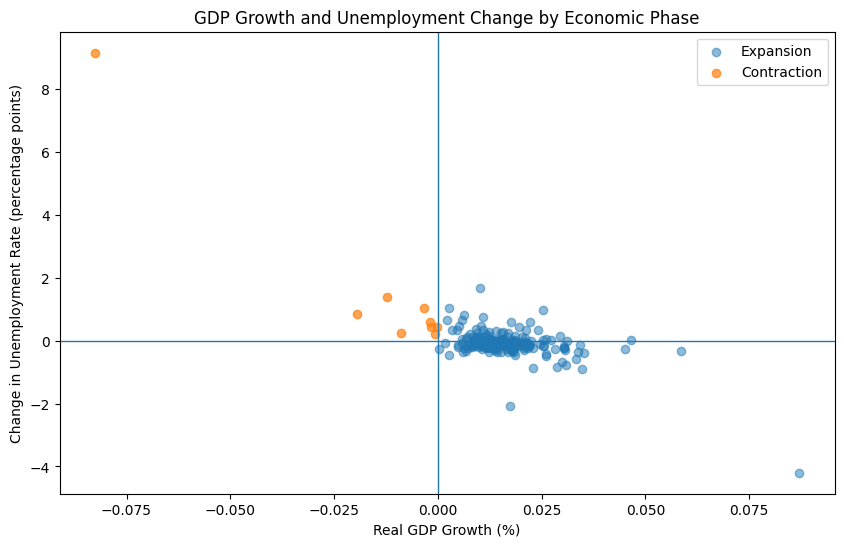

In [442]:
plt.figure(figsize=(10, 6))

plt.scatter(
    expansion["gdp_growth"],
    expansion["unemployment_change"],
    alpha=0.5,
    label="Expansion"
)

plt.scatter(
    contraction["gdp_growth"],
    contraction["unemployment_change"],
    alpha=0.7,
    label="Contraction"
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel("Real GDP Growth (%)")
plt.ylabel("Change in Unemployment Rate (percentage points)")
plt.title("GDP Growth and Unemployment Change by Economic Phase")
plt.legend()

plt.show()

### Major downturn

In [443]:
major_downturns = (
    df_economy[
        ["period", "gdp_growth", "unemployment_change"]
    ]
    .sort_values("gdp_growth")
    .head(15)
)

major_downturns

,period,gdp_growth,unemployment_change
185,2020-04-01,-0.0826,9.1667
139,2008-10-01,-0.0195,0.8667
140,2009-01-01,-0.0121,1.4000
184,2020-01-01,-0.0089,0.2333
141,2009-04-01,-0.0034,1.0333
32,1982-01-01,-0.0020,0.6000
67,1990-10-01,-0.0017,0.4333
136,2008-01-01,-0.0006,0.2000
110,2001-07-01,-0.0001,0.4333
160,2014-01-01,0.0003,-0.2667


### Largest unemployment increases

In [444]:
largest_unemployment_increases = (
    df_economy[
        ["period", "gdp_growth", "unemployment_change"]
    ]
    .sort_values("unemployment_change", ascending=False)
    .head(15)
)

largest_unemployment_increases

,period,gdp_growth,unemployment_change
185,2020-04-01,-0.0826,9.1667
4,1975-01-01,0.0103,1.6667
140,2009-01-01,-0.0121,1.4000
25,1980-04-01,0.0027,1.0333
141,2009-04-01,-0.0034,1.0333
3,1974-10-01,0.0254,0.9667
139,2008-10-01,-0.0195,0.8667
31,1981-10-01,0.0062,0.8333
35,1982-10-01,0.0108,0.7667
111,2001-10-01,0.0059,0.6667


### Covid

In [445]:
df_economy[df_economy["covid_flag"] == 1][
    ["period", "gdp_growth", "unemployment_change"]
]

,period,gdp_growth,unemployment_change
184,2020-01-01,-0.0089,0.2333
185,2020-04-01,-0.0826,9.1667
186,2020-07-01,0.0871,-4.2000
187,2020-10-01,0.0174,-2.0667
188,2021-01-01,0.0261,-0.5000


### Lags

In [446]:
lag_data = df_economy.dropna(
    subset=["gdp_growth_lag1", "unemployment_change"]
).copy()

In [447]:
X_lag = sm.add_constant(lag_data["gdp_growth_lag1"])
y_lag = lag_data["unemployment_change"]

lag_model = sm.OLS(y_lag, X_lag).fit()

print(lag_model.summary())

                             OLS Regression Results                            
Dep. Variable:     unemployment_change   R-squared:                       0.006
Model:                             OLS   Adj. R-squared:                  0.001
Method:                  Least Squares   F-statistic:                     1.158
Date:                 Fri, 18 Sep 2026   Prob (F-statistic):              0.283
Time:                         20:08:00   Log-Likelihood:                -238.71
No. Observations:                  199   AIC:                             481.4
Df Residuals:                      197   BIC:                             488.0
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0648      

### Contemporanous vs lagged

In [448]:
lag_comparison = pd.DataFrame({
    "Model": [
        "Contemporaneous",
        "One-quarter lag"
    ],
    "GDP_Coefficient": [
        model.params["gdp_growth"],
        lag_model.params["gdp_growth_lag1"]
    ],
    "P_Value": [
        model.pvalues["gdp_growth"],
        lag_model.pvalues["gdp_growth_lag1"]
    ],
    "R_Squared": [
        model.rsquared,
        lag_model.rsquared
    ]
})

lag_comparison

,Model,GDP_Coefficient,P_Value,R_Squared
0,Contemporaneous,-46.2666,0.0000,0.5324
1,One-quarter lag,-4.8489,0.2831,0.0058


### summary

In [449]:
summary_stats = {
    "Overall correlation": df_economy["gdp_growth"].corr(
        df_economy["unemployment_change"]
    ),
    
    "Overall coefficient": model.params["gdp_growth"],
    
    "Overall p-value": model.pvalues["gdp_growth"],
    
    "Overall R-squared": model.rsquared,
    
    "Expansion correlation": expansion_corr,
    
    "Contraction correlation": contraction_corr,
    
    "Expansion coefficient": model_exp.params["gdp_growth"],
    
    "Contraction coefficient": model_con.params["gdp_growth"],
    
    "Expansion R-squared": model_exp.rsquared,
    
    "Contraction R-squared": model_con.rsquared,
    
    "Lagged coefficient": lag_model.params["gdp_growth_lag1"],
    
    "Lagged p-value": lag_model.pvalues["gdp_growth_lag1"],
    
    "Lagged R-squared": lag_model.rsquared
}

pd.Series(summary_stats)

Overall correlation         -0.7297
Overall coefficient        -46.2666
Overall p-value              0.0000
Overall R-squared            0.5324
Expansion correlation       -0.5309
Contraction correlation     -0.9771
Expansion coefficient      -24.5020
Contraction coefficient   -106.3626
Expansion R-squared          0.2819
Contraction R-squared        0.9548
Lagged coefficient          -4.8489
Lagged p-value               0.2831
Lagged R-squared             0.0058
dtype: float64

# Question 7 — Growth and Inflation

## Is stronger economic growth consistently associated with higher inflation in the U.S. economy?

## 1. Economic Framework

### Inflation

Inflation refers to a sustained increase in the general price level of goods and services in an economy. In this analysis, inflation is measured using quarterly CPI growth (`cpi_growth`).

### Economic Growth

Economic growth refers to an increase in real economic output over time. Here, economic growth is measured using quarterly real GDP growth (`gdp_growth`).

The relationship between economic growth and inflation is theoretically important because stronger economic activity can increase aggregate demand and put upward pressure on prices. However, inflation can also be driven by supply-side factors, expectations, and external shocks. Therefore, the relationship is not necessarily stable across all periods.

---

## 2. Theoretical Relationships

### Phillips Curve

The Phillips Curve describes a relationship between economic slack and inflation. When economic activity is strong and unemployment is relatively low, inflationary pressure may increase.

However, the relationship is not necessarily a simple or permanent trade-off. Inflation expectations and supply-side shocks can alter the relationship.

### Aggregate Demand

An increase in aggregate demand can increase both real output and the price level in the short run, particularly when the economy has unused capacity.

Therefore, demand-driven expansions can generate a positive relationship between GDP growth and inflation.

### Aggregate Supply

Changes in aggregate supply can affect inflation independently of economic growth.

For example, an increase in energy or production costs can raise prices while reducing real output. This creates a situation in which inflation and growth move in opposite directions.

### Demand-Pull Inflation

Demand-pull inflation occurs when aggregate demand grows faster than the economy's productive capacity.

In such circumstances, stronger economic growth may be accompanied by higher inflation.

### Cost-Push Inflation

Cost-push inflation occurs when production costs increase, causing firms to raise prices.

Supply shocks can therefore generate higher inflation without stronger economic growth, weakening the simple positive relationship between growth and inflation.

---

# 3. Empirical Analysis

## GDP Growth and Inflation

The full sample contains **200 quarterly observations**.

The mean quarterly GDP growth rate is approximately **1.49%**, while the mean quarterly CPI growth rate is approximately **0.95%**.

The correlation between GDP growth and CPI growth is:

> **0.5105**

This indicates a **moderate positive correlation** between economic growth and inflation in the sample.

Therefore, periods of stronger GDP growth tend to be associated with higher CPI growth. However, the correlation is far from 1, indicating that GDP growth alone does not fully explain movements in inflation.

### Descriptive Statistics

| Statistic          | GDP Growth | CPI Growth |
| ------------------ | ---------: | ---------: |
| Mean               |     0.0149 |     0.0095 |
| Standard Deviation |     0.0127 |     0.0080 |
| Minimum            |    -0.0826 |    -0.0229 |
| 25th Percentile    |     0.0103 |     0.0053 |
| Median             |     0.0138 |     0.0079 |
| 75th Percentile    |     0.0191 |     0.0115 |
| Maximum            |     0.0871 |     0.0395 |

The data also show substantial variation in both variables. The minimum GDP growth observation is **-8.26%**, corresponding to the sharp contraction during the COVID-19 shock, while the maximum is **8.71%**.

---

## High-Growth Periods

High-growth periods are defined as observations where GDP growth is at or above its 75th percentile:

> **High-growth threshold = 1.91%**

There are **50 high-growth observations**.

During these periods:

* Average GDP growth = **2.82%**
* Average CPI growth = **1.68%**

The average inflation rate during high-growth periods is therefore substantially above the full-sample average of 0.95%.

This provides descriptive evidence that stronger economic activity has often coincided with stronger inflationary pressure.

---

## Low-Growth Periods

Low-growth periods are defined as observations where GDP growth is at or below its 25th percentile:

> **Low-growth threshold = 1.03%**

There are **50 low-growth observations**.

During these periods:

* Average GDP growth = **0.31%**
* Average CPI growth = **0.55%**

Compared with high-growth periods, inflation is considerably lower during low-growth periods.

### High-Growth vs. Low-Growth

| Group       | Average GDP Growth | Average CPI Growth | Observations |
| ----------- | -----------------: | -----------------: | -----------: |
| High Growth |              2.82% |              1.68% |           50 |
| Low Growth  |              0.31% |              0.55% |           50 |

The difference in average CPI growth between the two groups is consistent with a positive growth-inflation relationship.

However, this comparison is descriptive and does not establish that stronger growth causes higher inflation.

---

# 4. Recession Periods

For this analysis, a recession-like observation is operationally defined as a quarter with negative GDP growth:

> `gdp_growth < 0`

This is a simplified dataset-based definition and **should not be interpreted as the official NBER recession chronology**.

There are **9 observations** meeting this criterion.

Average values are:

| Period Type             | Average GDP Growth | Average CPI Growth |
| ----------------------- | -----------------: | -----------------: |
| Non-negative GDP growth |              1.63% |              0.99% |
| Negative GDP growth     |             -1.46% |              0.10% |

Inflation is substantially lower, on average, during quarters with negative GDP growth.

Several recession-like observations show outright negative CPI growth:

* 2008 Q4: GDP growth = -1.95%, CPI growth = -2.29%
* 2009 Q1: GDP growth = -1.21%, CPI growth = -0.69%
* 2020 Q2: GDP growth = -8.26%, CPI growth = -0.94%

However, negative GDP growth does not always coincide with low inflation. For example:

* 1982 Q1: GDP growth = -0.20%, CPI growth = 0.89%
* 1990 Q4: GDP growth = -0.17%, CPI growth = 1.70%
* 2008 Q1: GDP growth = -0.06%, CPI growth = 1.08%

This demonstrates that the relationship between economic contractions and inflation is not uniform.

---

# 5. High Inflation and Stagflation-Like Observations

The 75th percentile of CPI growth is:

> **High-inflation threshold = 1.15%**

An observation is classified as **stagflation-like** in this dataset when:

* GDP growth is negative, and
* CPI growth is at or above the 75th percentile.

This is an **operational definition created for this analysis**, not an official definition of stagflation.

Only **one observation** satisfies both conditions:

| Period  | GDP Growth | CPI Growth |
| ------- | ---------: | ---------: |
| 1990 Q4 |     -0.17% |      1.70% |

This result illustrates an important point: high inflation can occur even when economic growth is weak or negative.

---

# 6. High Growth and High Inflation

To identify periods in which strong economic activity coincided with relatively high inflation, observations were classified as high-growth and high-inflation when both variables were at or above their respective 75th percentiles.

The thresholds are:

* GDP growth ≥ **1.91%**
* CPI growth ≥ **1.15%**

Several observations satisfy both conditions.

Examples include periods during:

* the mid-to-late 1970s,
* the late 1970s and early 1980s,
* and the post-COVID recovery.

These observations demonstrate that high economic growth and high inflation can occur simultaneously, particularly during periods of strong demand or economic reopening.

---

# 7. Low Growth and High Inflation

The analysis also identifies observations where:

* GDP growth ≤ **1.03%**
* CPI growth ≥ **1.15%**

There are **5 such observations** in the sample.

These include:

| Period  | GDP Growth | CPI Growth |
| ------- | ---------: | ---------: |
| 1980 Q2 |      0.27% |      3.37% |
| 1981 Q4 |      0.62% |      1.63% |
| 1990 Q3 |      0.92% |      1.73% |
| 1990 Q4 |     -0.17% |      1.70% |
| 2008 Q3 |      0.22% |      1.54% |

These observations are particularly important for answering the research question.

They show that **higher inflation is not exclusively associated with stronger economic growth**. Inflation can remain elevated even when GDP growth is weak.

This is consistent with the possibility of supply-side pressures and other inflationary forces that are not captured by GDP growth alone.

---

# 8. Statistical Analysis

## Correlation

The Pearson correlation between GDP growth and CPI growth is:

> **r = 0.5105**

This represents a moderate positive linear relationship.

In general, quarters with stronger GDP growth tend to have higher CPI growth.

However, the correlation is not sufficiently strong to suggest that economic growth alone determines inflation.

---

## Regression

A simple OLS regression was estimated:

$$
CPIGrowth_t = \alpha + \beta GDPGrowth_t + \epsilon_t
$$

The estimated model is:

$$
CPIGrowth_t = 0.0047 + 0.3217GDPGrowth_t
$$

### Regression Results

| Statistic              |   Value |
| ---------------------- | ------: |
| GDP Growth coefficient |  0.3217 |
| p-value                | < 0.001 |
| R²                     |  0.2606 |
| Observations           |     200 |

The coefficient on GDP growth is positive and statistically significant.

The estimated coefficient of **0.3217** means that, within this simple model, a one-unit increase in quarterly GDP growth is associated with an approximately **0.322 percentage-point increase in quarterly CPI growth**, on average.

The relationship is statistically significant, but the model explains only approximately **26.1% of the variation in CPI growth**.

Therefore, approximately three-quarters of the variation in inflation remains unexplained by GDP growth alone.

This is consistent with the broader economic framework: inflation is influenced by many factors beyond real economic growth.

---

# 9. Historical Episodes

## Post-2008 Period

The post-2008 period is defined here as observations beginning in 2009 Q1.

The correlation between GDP growth and CPI growth during this period is:

> **0.5560**

This is slightly higher than the full-sample correlation of 0.5105.

Average values during the post-2008 period are:

* Average GDP growth = **1.10%**
* Average CPI growth = **0.61%**

The highest CPI-growth observations in this period occurred mainly around **2021–2022**, while several periods of very low or negative inflation occurred following the Global Financial Crisis and during parts of the mid-2010s.

This indicates that the growth-inflation relationship continued to exist after 2008, but inflation dynamics varied considerably across different episodes.

---

## COVID-19 Period

The COVID period is defined as 2020 Q1 through 2021 Q2 in the dataset.

The average values during this period were:

* Average GDP growth = **1.16%**
* Average CPI growth = **0.69%**

The correlation between GDP growth and CPI growth during these observations is:

> **0.8379**

This is substantially higher than the full-sample correlation.

However, the COVID period contains unusually large movements in both variables, including the sharp contraction in 2020 Q2 and the subsequent rebound in 2020 Q3.

Therefore, the high correlation should not be interpreted as evidence of a stable structural relationship. With only **13 observations**, the COVID-period correlation is particularly sensitive to individual observations and the unusual economic conditions of the period.

---

## Post-COVID Inflation

The post-COVID period, beginning in 2021 Q1, shows:

* Average GDP growth = **1.94%**
* Average CPI growth = **1.32%**
* GDP growth–CPI growth correlation = **0.5830**

The highest CPI growth observations occurred between 2021 Q2 and 2022 Q2.

For example:

| Period  | GDP Growth | CPI Growth |
| ------- | ---------: | ---------: |
| 2021 Q2 |      3.06% |      1.88% |
| 2021 Q3 |      2.30% |      1.59% |
| 2021 Q4 |      3.46% |      2.12% |
| 2022 Q1 |      1.52% |      2.21% |
| 2022 Q2 |      2.06% |      2.42% |

The post-COVID period therefore provides several examples of strong economic growth occurring alongside relatively high inflation.

At the same time, the data also show that inflation remained elevated across quarters with different rates of GDP growth, indicating that factors beyond output growth were also important.

---

# 10. Overall Historical Comparison

| Period       | Average GDP Growth | Average CPI Growth | Correlation |
| ------------ | -----------------: | -----------------: | ----------: |
| Full Sample  |              1.49% |              0.95% |      0.5105 |
| Post-2008    |              1.10% |              0.61% |      0.5560 |
| COVID Period |              1.16% |              0.69% |      0.8379 |
| Post-COVID   |              1.94% |              1.32% |      0.5830 |

The positive correlation is present across the full sample, post-2008 period, and post-COVID period.

The COVID period shows a particularly strong correlation, but its small sample size and exceptional economic conditions make it inappropriate to interpret this as evidence of a permanent structural relationship.

---

# 11. Economic Interpretation

The empirical results provide evidence of a **positive association between real GDP growth and CPI growth** in the U.S. quarterly data.

Several findings support this conclusion:

1. The full-sample correlation is positive at **0.5105**.
2. The OLS coefficient is positive (**0.3217**) and statistically significant.
3. High-growth quarters have substantially higher average CPI growth than low-growth quarters.
4. The post-2008 and post-COVID periods also display positive growth-inflation correlations.
5. Several periods combine strong GDP growth with relatively high inflation.

However, the relationship is **not consistent across every observation**.

The existence of low-growth/high-inflation observations demonstrates that inflation can remain elevated even when economic growth is weak. Similarly, recession-like quarters generally show lower inflation, but this is not universal.

The results are therefore more consistent with the interpretation that **economic growth is one important factor associated with inflation, rather than a sufficient explanation for inflation dynamics**.

From a macroeconomic perspective, this is consistent with multiple inflation channels:

* stronger aggregate demand can increase price pressures;
* supply shocks can raise inflation independently of output growth;
* energy and commodity prices can affect the price level;
* inflation expectations can influence current inflation;
* monetary and fiscal conditions can affect both demand and prices.

---

# 12. Limitations

Several limitations should be considered when interpreting the results.

### 1. Correlation Does Not Imply Causation

The positive correlation between GDP growth and CPI growth does not establish that higher GDP growth causes higher inflation.

### 2. Simple Regression Specification

The regression contains only GDP growth as an explanatory variable.

Important determinants of inflation—such as monetary policy, unemployment, interest rates, energy prices, exchange rates, inflation expectations, and supply shocks—are omitted.

### 3. Potential Endogeneity

GDP growth and inflation can influence each other simultaneously. Therefore, the OLS coefficient should be interpreted as an association rather than a causal effect.

### 4. Time-Series Dependence

The Durbin-Watson statistic is approximately **0.80**, suggesting positive serial correlation in the regression residuals.

Therefore, the standard OLS inference should be interpreted cautiously.

### 5. Non-Normal Residuals and Outliers

The Jarque-Bera and Omnibus tests indicate deviations from normality, while the COVID period contains unusually large observations.

These extreme observations can influence the estimated relationship.

### 6. Operational Recession Definition

The analysis defines recession-like observations using negative GDP growth. This is a simplified analytical definition and does not reproduce the official recession dating methodology.

### 7. Historical Coverage

The analysis does not separately estimate the 1970s relationship because the available observations for that period were incomplete in the dataset.

---

# 13. Conclusion

The evidence indicates a **moderate positive relationship between economic growth and inflation** in the U.S. quarterly data.

The full-sample correlation is **0.5105**, while the OLS coefficient on GDP growth is **0.3217** and statistically significant. High-growth periods also exhibit higher average CPI growth than low-growth periods.

However, the relationship is not universal. The presence of low-growth/high-inflation observations demonstrates that inflation can arise even when economic activity is weak. This highlights the importance of supply-side factors and other macroeconomic determinants.

The COVID and post-COVID periods further illustrate that the growth-inflation relationship can vary substantially across economic episodes.

Overall, the results suggest that **stronger economic growth is generally associated with higher inflation in the sample, but GDP growth alone is insufficient to explain inflation dynamics**.


### Dataframe observasion

In [450]:
df_economy.columns.tolist()

['year',
 'quarter',
 'year-quarter',
 'gdp',
 'cpi',
 'unemployment_rate',
 'gdp_growth',
 'cpi_growth',
 'unemployment_change',
 'gdp_yoy',
 'cpi_yoy',
 'unemployment_yoy_change',
 'gdp_rolling_mean_4q',
 'cpi_rolling_mean_4q',
 'unemployment_rolling_mean_4q',
 'gdp_volatility_4q',
 'cpi_volatility_4q',
 'unemployment_volatility_4q',
 'gdp_growth_lag1',
 'gdp_growth_lag2',
 'cpi_growth_lag1',
 'unemployment_change_lag1',
 'covid_flag',
 'recession_flag',
 'high_growth_flag',
 'period',
 'phase']

In [451]:
df_economy[
    ["period", "gdp_growth", "cpi_growth"]
].head(10)

,period,gdp_growth,cpi_growth
0,1974-01-01,NaN,NaN
1,1974-04-01,0.0261,0.0268
2,1974-07-01,0.0196,0.0281
3,1974-10-01,0.0254,0.0307
4,1975-01-01,0.0103,0.0214
5,1975-04-01,0.0221,0.0120
6,1975-07-01,0.0351,0.0201
7,1975-10-01,0.0304,0.0184
8,1976-01-01,0.0333,0.0115
9,1976-04-01,0.0175,0.0089


### Desciptive statistics

In [452]:
df_economy[
    ["gdp_growth", "cpi_growth"]
].describe()

,gdp_growth,cpi_growth
count,200.0000,200.0000
mean,0.0149,0.0095
std,0.0127,0.0080
min,-0.0826,-0.0229
25%,0.0103,0.0053
50%,0.0138,0.0079
75%,0.0191,0.0115
max,0.0871,0.0395


#### Correlation

In [453]:
growth_inflation_corr = (
    df_economy["gdp_growth"]
    .corr(df_economy["cpi_growth"])
)

print(
    f"GDP Growth–CPI Growth Correlation: "
    f"{growth_inflation_corr:.4f}"
)

GDP Growth–CPI Growth Correlation: 0.5105


### Scatter plot

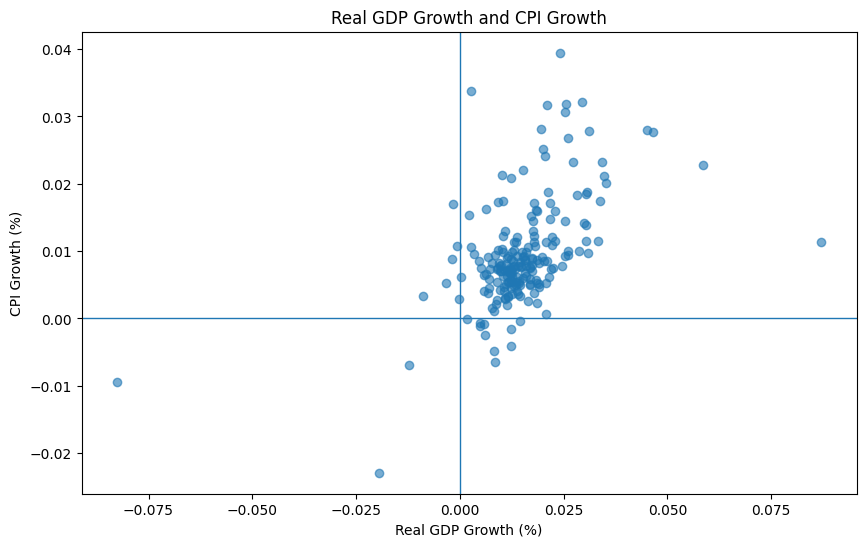

In [454]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_economy["gdp_growth"],
    df_economy["cpi_growth"],
    alpha=0.6
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel("Real GDP Growth (%)")
plt.ylabel("CPI Growth (%)")
plt.title("Real GDP Growth and CPI Growth")

plt.show()

### Regression

In [455]:
growth_inflation_data = df_economy[
    ["gdp_growth", "cpi_growth"]
].dropna().copy()

In [456]:
X = sm.add_constant(
    growth_inflation_data["gdp_growth"]
)

y = growth_inflation_data["cpi_growth"]

growth_inflation_model = sm.OLS(y, X).fit()

In [457]:
growth_inflation_model.params

const        0.0047
gdp_growth   0.3217
dtype: float64

In [458]:
print(growth_inflation_model.summary())

                            OLS Regression Results                            
Dep. Variable:             cpi_growth   R-squared:                       0.261
Model:                            OLS   Adj. R-squared:                  0.257
Method:                 Least Squares   F-statistic:                     69.77
Date:                Fri, 18 Sep 2026   Prob (F-statistic):           1.15e-14
Time:                        20:08:00   Log-Likelihood:                 712.45
No. Observations:                 200   AIC:                            -1421.
Df Residuals:                     198   BIC:                            -1414.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0047      0.001      6.210      0.0

### regression line

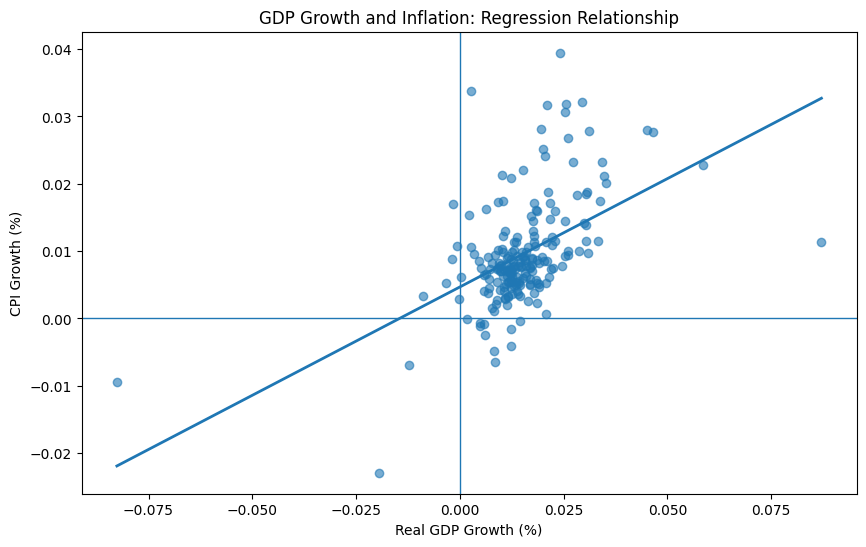

In [459]:
plt.figure(figsize=(10, 6))

plt.scatter(
    growth_inflation_data["gdp_growth"],
    growth_inflation_data["cpi_growth"],
    alpha=0.6
)

x_values = np.linspace(
    growth_inflation_data["gdp_growth"].min(),
    growth_inflation_data["gdp_growth"].max(),
    100
)

X_line = sm.add_constant(x_values)

y_pred = growth_inflation_model.predict(X_line)

plt.plot(
    x_values,
    y_pred,
    linewidth=2
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel("Real GDP Growth (%)")
plt.ylabel("CPI Growth (%)")
plt.title("GDP Growth and Inflation: Regression Relationship")

plt.show()

### regression results

In [460]:
growth_inflation_beta = (
    growth_inflation_model.params["gdp_growth"]
)

growth_inflation_pvalue = (
    growth_inflation_model.pvalues["gdp_growth"]
)

growth_inflation_r2 = (
    growth_inflation_model.rsquared
)

print(f"Coefficient: {growth_inflation_beta:.4f}")
print(f"P-value: {growth_inflation_pvalue:.4f}")
print(f"R-squared: {growth_inflation_r2:.4f}")

Coefficient: 0.3217
P-value: 0.0000
R-squared: 0.2606


### High growth periods

In [461]:
high_growth_threshold = df_economy["gdp_growth"].quantile(0.75)

print(
    f"75th percentile of GDP growth: "
    f"{high_growth_threshold:.4f}"
)

75th percentile of GDP growth: 0.0191


In [462]:
df_economy["growth_group"] = np.where(
    df_economy["gdp_growth"] >= high_growth_threshold,
    "High Growth",
    "Other"
)

In [463]:
df_economy["growth_group"].value_counts()

growth_group
Other          151
High Growth     50
Name: count, dtype: int64

In [464]:
high_growth_stats = (
    df_economy[
        df_economy["growth_group"] == "High Growth"
    ][
        ["gdp_growth", "cpi_growth"]
    ]
    .describe()
)

high_growth_stats

,gdp_growth,cpi_growth
count,50.0000,50.0000
mean,0.0282,0.0168
std,0.0114,0.0089
min,0.0192,0.0007
25%,0.0215,0.0098
50%,0.0254,0.0146
75%,0.0304,0.0233
max,0.0871,0.0395


In [465]:
high_growth_means = (
    df_economy
    .groupby("growth_group")[["gdp_growth", "cpi_growth"]]
    .mean()
)

high_growth_means

,gdp_growth,cpi_growth
growth_group,,
High Growth,0.0282,0.0168
Other,0.0105,0.0070


### Low growth periods

In [466]:
low_growth_threshold = df_economy["gdp_growth"].quantile(0.25)

print(
    f"25th percentile of GDP growth: "
    f"{low_growth_threshold:.4f}"
)

25th percentile of GDP growth: 0.0103


In [467]:
df_economy["low_growth"] = np.where(
    df_economy["gdp_growth"] <= low_growth_threshold,
    "Low Growth",
    "Other"
)

In [468]:
low_growth_stats = (
    df_economy[
        df_economy["low_growth"] == "Low Growth"
    ][
        ["gdp_growth", "cpi_growth"]
    ]
    .describe()
)

low_growth_stats

,gdp_growth,cpi_growth
count,50.0000,50.0000
mean,0.0031,0.0055
std,0.0137,0.0081
min,-0.0826,-0.0229
25%,0.0027,0.0023
50%,0.0064,0.0066
75%,0.0088,0.0088
max,0.0102,0.0337


In [469]:
low_growth_means = (
    df_economy
    .groupby("low_growth")[["gdp_growth", "cpi_growth"]]
    .mean()
)

low_growth_means

,gdp_growth,cpi_growth
low_growth,,
Low Growth,0.0031,0.0055
Other,0.0188,0.0108


### High vs Low growth

In [470]:
growth_comparison = pd.DataFrame({
    "Group": [
        "High Growth",
        "Low Growth"
    ],
    "Average GDP Growth": [
        df_economy.loc[
            df_economy["gdp_growth"] >= high_growth_threshold,
            "gdp_growth"
        ].mean(),
        
        df_economy.loc[
            df_economy["gdp_growth"] <= low_growth_threshold,
            "gdp_growth"
        ].mean()
    ],
    "Average CPI Growth": [
        df_economy.loc[
            df_economy["gdp_growth"] >= high_growth_threshold,
            "cpi_growth"
        ].mean(),
        
        df_economy.loc[
            df_economy["gdp_growth"] <= low_growth_threshold,
            "cpi_growth"
        ].mean()
    ],
    "Observations": [
        (
            df_economy["gdp_growth"] >= high_growth_threshold
        ).sum(),
        
        (
            df_economy["gdp_growth"] <= low_growth_threshold
        ).sum()
    ]
})

growth_comparison

,Group,Average GDP Growth,Average CPI Growth,Observations
0,High Growth,0.0282,0.0168,50
1,Low Growth,0.0031,0.0055,50


### Recession periods

In [471]:
df_economy["recession_flag"] = (
    df_economy["gdp_growth"] < 0
)

In [472]:
df_economy["recession_flag"].value_counts()

recession_flag
False    192
True       9
Name: count, dtype: int64

In [473]:
recession_comparison = (
    df_economy
    .groupby("recession_flag")[
        ["gdp_growth", "cpi_growth"]
    ]
    .mean()
)

recession_comparison

,gdp_growth,cpi_growth
recession_flag,,
False,0.0163,0.0099
True,-0.0146,0.0010


In [474]:
recession_inflation = (
    df_economy[
        df_economy["recession_flag"]
    ][
        ["period", "gdp_growth", "cpi_growth"]
    ]
    .sort_values("period")
)

recession_inflation

,period,gdp_growth,cpi_growth
32,1982-01-01,-0.0020,0.0089
67,1990-10-01,-0.0017,0.0170
110,2001-07-01,-0.0001,0.0028
136,2008-01-01,-0.0006,0.0108
139,2008-10-01,-0.0195,-0.0229
140,2009-01-01,-0.0121,-0.0069
141,2009-04-01,-0.0034,0.0053
184,2020-01-01,-0.0089,0.0034
185,2020-04-01,-0.0826,-0.0094


In [475]:
recession_inflation.sort_values(
    "cpi_growth",
    ascending=False
).head(15)

,period,gdp_growth,cpi_growth
67,1990-10-01,-0.0017,0.0170
136,2008-01-01,-0.0006,0.0108
32,1982-01-01,-0.0020,0.0089
141,2009-04-01,-0.0034,0.0053
184,2020-01-01,-0.0089,0.0034
110,2001-07-01,-0.0001,0.0028
140,2009-01-01,-0.0121,-0.0069
185,2020-04-01,-0.0826,-0.0094
139,2008-10-01,-0.0195,-0.0229


### Stagflation

In [476]:
inflation_high_threshold = (
    df_economy["cpi_growth"].quantile(0.75)
)

print(
    f"75th percentile of CPI growth: "
    f"{inflation_high_threshold:.4f}"
)

75th percentile of CPI growth: 0.0115


In [477]:
df_economy["stagflation_flag"] = (
    (df_economy["gdp_growth"] < 0) &
    (df_economy["cpi_growth"] >= inflation_high_threshold)
)

In [478]:
stagflation_periods = (
    df_economy[
        df_economy["stagflation_flag"]
    ][
        ["period", "gdp_growth", "cpi_growth"]
    ]
    .sort_values("period")
)

stagflation_periods

,period,gdp_growth,cpi_growth
67,1990-10-01,-0.0017,0.0170


In [479]:
print(
    f"Number of stagflation-like observations: "
    f"{len(stagflation_periods)}"
)

Number of stagflation-like observations: 1


### post 2008

In [480]:
post_2008 = df_economy[
    df_economy["period"] >= "2009-01-01"
][
    ["period", "gdp_growth", "cpi_growth"]
].copy()

In [481]:
post_2008[
    ["gdp_growth", "cpi_growth"]
].describe()

,gdp_growth,cpi_growth
count,61.0000,61.0000
mean,0.0110,0.0061
std,0.0174,0.0061
min,-0.0826,-0.0094
25%,0.0069,0.0034
50%,0.0112,0.0056
75%,0.0146,0.0081
max,0.0871,0.0242


In [482]:
post_2008_corr = (
    post_2008["gdp_growth"]
    .corr(post_2008["cpi_growth"])
)

print(
    f"Post-2008 GDP Growth–CPI Growth Correlation: "
    f"{post_2008_corr:.4f}"
)

Post-2008 GDP Growth–CPI Growth Correlation: 0.5560


### post 2008 inflation episodes

In [483]:
post_2008.sort_values(
    "cpi_growth",
    ascending=False
).head(15)

,period,gdp_growth,cpi_growth
193,2022-04-01,0.0206,0.0242
192,2022-01-01,0.0152,0.0221
191,2021-10-01,0.0346,0.0212
189,2021-04-01,0.0306,0.0188
190,2021-07-01,0.0230,0.0159
194,2022-07-01,0.0176,0.0130
186,2020-07-01,0.0871,0.0114
149,2011-04-01,0.0134,0.0114
148,2011-01-01,0.0027,0.0107
188,2021-01-01,0.0261,0.0100


In [484]:
post_2008.sort_values(
    "cpi_growth"
).head(15)

,period,gdp_growth,cpi_growth
185,2020-04-01,-0.0826,-0.0094
140,2009-01-01,-0.0121,-0.0069
164,2015-01-01,0.0085,-0.0065
163,2014-10-01,0.0061,-0.0025
157,2013-04-01,0.0048,-0.0011
168,2016-01-01,0.0049,-0.0006
145,2010-04-01,0.0146,-0.0004
167,2015-10-01,0.0018,-0.0001
173,2017-04-01,0.0082,0.0012
144,2010-01-01,0.0077,0.0016


### Covid inflation

In [485]:
covid_period = df_economy[
    (df_economy["period"] >= "2020-01-01") &
    (df_economy["period"] <= "2021-04-01")
][
    ["period", "gdp_growth", "cpi_growth"]
]

covid_period

,period,gdp_growth,cpi_growth
184,2020-01-01,-0.0089,0.0034
185,2020-04-01,-0.0826,-0.0094
186,2020-07-01,0.0871,0.0114
187,2020-10-01,0.0174,0.0070
188,2021-01-01,0.0261,0.0100
189,2021-04-01,0.0306,0.0188


### post covid inflation

In [486]:
post_covid = df_economy[
    df_economy["period"] >= "2021-01-01"
][
    ["period", "gdp_growth", "cpi_growth"]
].copy()

post_covid.sort_values(
    "cpi_growth",
    ascending=False
).head(15)

,period,gdp_growth,cpi_growth
193,2022-04-01,0.0206,0.0242
192,2022-01-01,0.0152,0.0221
191,2021-10-01,0.0346,0.0212
189,2021-04-01,0.0306,0.0188
190,2021-07-01,0.0230,0.0159
194,2022-07-01,0.0176,0.0130
188,2021-01-01,0.0261,0.0100
195,2022-10-01,0.0159,0.0099
196,2023-01-01,0.0153,0.0093
198,2023-07-01,0.0202,0.0085


In [487]:
post_covid[
    ["gdp_growth", "cpi_growth"]
].describe()

,gdp_growth,cpi_growth
count,13.0000,13.0000
mean,0.0194,0.0132
std,0.0076,0.0064
min,0.0093,0.0051
25%,0.0152,0.0085
50%,0.0176,0.0100
75%,0.0230,0.0188
max,0.0346,0.0242


### plot

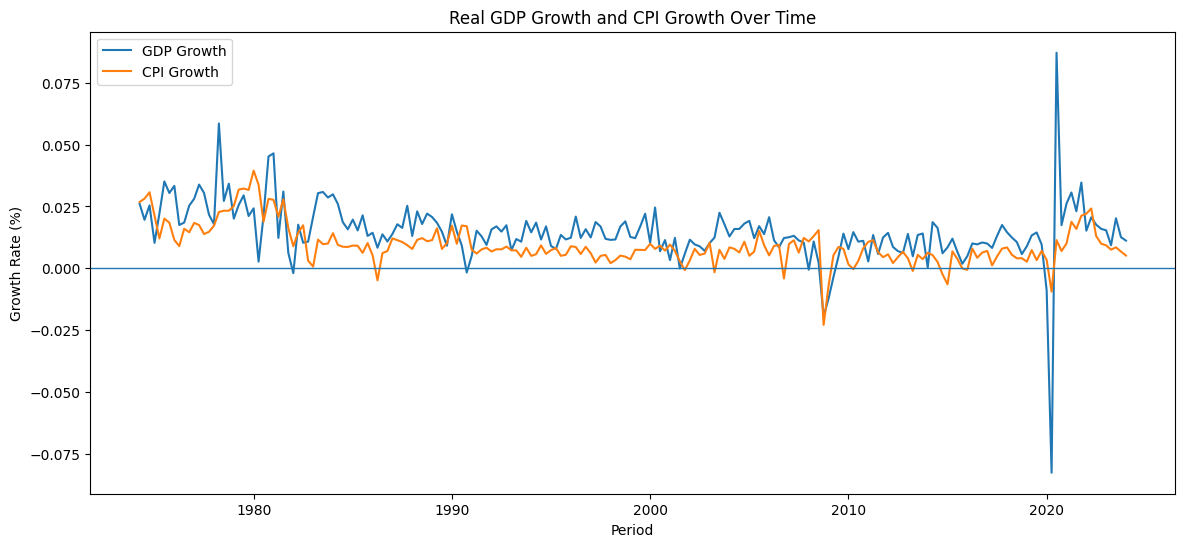

In [488]:
plt.figure(figsize=(14, 6))

plt.plot(
    df_economy["period"],
    df_economy["gdp_growth"],
    label="GDP Growth"
)

plt.plot(
    df_economy["period"],
    df_economy["cpi_growth"],
    label="CPI Growth"
)

plt.axhline(0, linewidth=1)

plt.xlabel("Period")
plt.ylabel("Growth Rate (%)")
plt.title("Real GDP Growth and CPI Growth Over Time")
plt.legend()

plt.show()

### rolling correlation

In [489]:
rolling_corr = (
    df_economy[
        ["gdp_growth", "cpi_growth"]
    ]
    .rolling(window=16)
    .corr()
    .iloc[0::2, -1]
)

In [490]:
rolling_corr_df = pd.DataFrame({
    "period": df_economy["period"].values,
    "rolling_correlation": rolling_corr.values
})

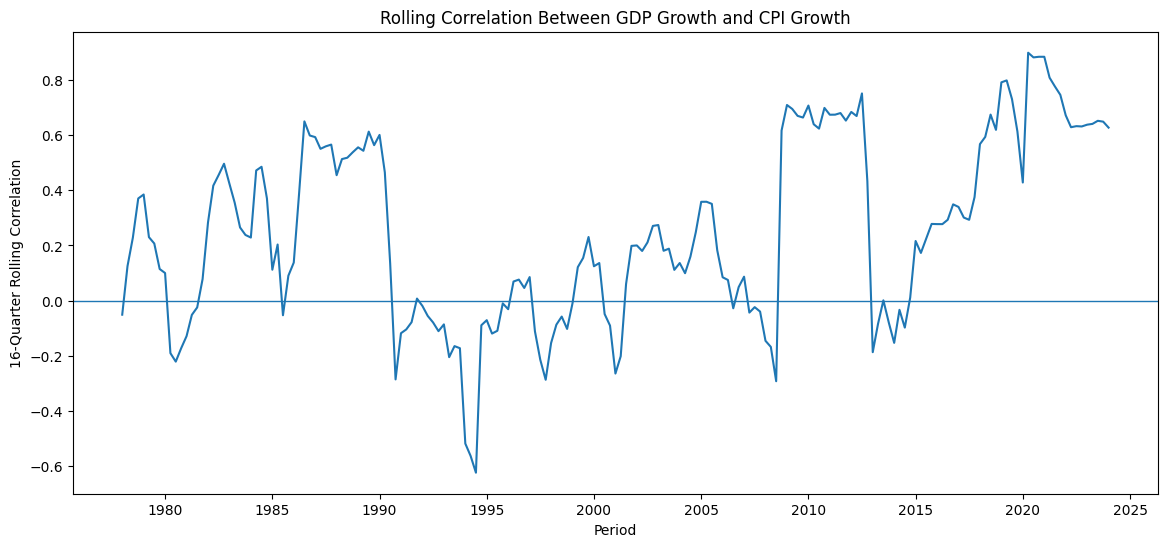

In [491]:
plt.figure(figsize=(14, 6))

plt.plot(
    rolling_corr_df["period"],
    rolling_corr_df["rolling_correlation"]
)

plt.axhline(0, linewidth=1)

plt.xlabel("Period")
plt.ylabel("16-Quarter Rolling Correlation")
plt.title("Rolling Correlation Between GDP Growth and CPI Growth")

plt.show()

### high growth and high inflation periods

In [492]:
high_growth_high_inflation = df_economy[
    (df_economy["gdp_growth"] >= high_growth_threshold) &
    (df_economy["cpi_growth"] >= inflation_high_threshold)
][
    ["period", "gdp_growth", "cpi_growth"]
].sort_values("period")

high_growth_high_inflation

,period,gdp_growth,cpi_growth
1,1974-04-01,0.0261,0.0268
2,1974-07-01,0.0196,0.0281
3,1974-10-01,0.0254,0.0307
5,1975-04-01,0.0221,0.0120
6,1975-07-01,0.0351,0.0201
7,1975-10-01,0.0304,0.0184
11,1976-10-01,0.0253,0.0145
12,1977-01-01,0.0281,0.0183
13,1977-04-01,0.0338,0.0175
14,1977-07-01,0.0304,0.0138


In [493]:
print(
    f"High-growth & high-inflation observations: "
    f"{len(high_growth_high_inflation)}"
)

High-growth & high-inflation observations: 31


### low growth + high inflation

In [494]:
low_growth_high_inflation = df_economy[
    (df_economy["gdp_growth"] <= low_growth_threshold) &
    (df_economy["cpi_growth"] >= inflation_high_threshold)
][
    ["period", "gdp_growth", "cpi_growth"]
].sort_values("period")

low_growth_high_inflation

,period,gdp_growth,cpi_growth
25,1980-04-01,0.0027,0.0337
31,1981-10-01,0.0062,0.0163
66,1990-07-01,0.0092,0.0173
67,1990-10-01,-0.0017,0.0170
138,2008-07-01,0.0022,0.0154


In [495]:
low_growth_high_inflation = df_economy[
    (df_economy["gdp_growth"] <= low_growth_threshold) &
    (df_economy["cpi_growth"] >= inflation_high_threshold)
][
    ["period", "gdp_growth", "cpi_growth"]
].sort_values("period")

low_growth_high_inflation

,period,gdp_growth,cpi_growth
25,1980-04-01,0.0027,0.0337
31,1981-10-01,0.0062,0.0163
66,1990-07-01,0.0092,0.0173
67,1990-10-01,-0.0017,0.0170
138,2008-07-01,0.0022,0.0154


### Growth-Inflation summary table

In [496]:
growth_inflation_summary = pd.DataFrame({
    "Metric": [
        "Overall correlation",
        "Regression coefficient",
        "Regression p-value",
        "R-squared",
        "High-growth threshold",
        "Low-growth threshold",
        "High-inflation threshold",
        "Post-2008 correlation"
    ],
    
    "Value": [
        growth_inflation_corr,
        growth_inflation_model.params["gdp_growth"],
        growth_inflation_model.pvalues["gdp_growth"],
        growth_inflation_model.rsquared,
        high_growth_threshold,
        low_growth_threshold,
        inflation_high_threshold,
        post_2008_corr
    ]
})

growth_inflation_summary

,Metric,Value
0,Overall correlation,0.5105
1,Regression coefficient,0.3217
2,Regression p-value,0.0000
3,R-squared,0.2606
4,High-growth threshold,0.0191
5,Low-growth threshold,0.0103
6,High-inflation threshold,0.0115
7,Post-2008 correlation,0.5560


In [497]:
historical_comparison = pd.DataFrame({
    "Period": [
        "Full Sample",
        "Post-2008",
        "COVID Period",
        "Post-COVID"
    ],
    
    "Average GDP Growth": [
        df_economy["gdp_growth"].mean(),
        post_2008["gdp_growth"].mean(),
        covid_period["gdp_growth"].mean(),
        post_covid["gdp_growth"].mean()
    ],
    
    "Average CPI Growth": [
        df_economy["cpi_growth"].mean(),
        post_2008["cpi_growth"].mean(),
        covid_period["cpi_growth"].mean(),
        post_covid["cpi_growth"].mean()
    ],
    
    "Correlation": [
        growth_inflation_corr,
        post_2008_corr,
        covid_period["gdp_growth"].corr(
            covid_period["cpi_growth"]
        ),
        post_covid["gdp_growth"].corr(
            post_covid["cpi_growth"]
        )
    ]
})

historical_comparison

,Period,Average GDP Growth,Average CPI Growth,Correlation
0,Full Sample,0.0149,0.0095,0.5105
1,Post-2008,0.0110,0.0061,0.5560
2,COVID Period,0.0116,0.0069,0.8379
3,Post-COVID,0.0194,0.0132,0.5830
